In [1]:
# from torchvision.datasets import OxfordIIITPet
# import matplotlib.pyplot as plt

# # Cela télécharge les images (environ 800 Mo) automatiquement dans un dossier 'data'
# # target_types='segmentation' télécharge aussi les masques pour la segmentation
# dataset = OxfordIIITPet(root='./data', split='trainval', target_types='segmentation', download=True)

# print("Téléchargement terminé !")

# # Vérification : Afficher un masque pour voir si ça marche
# mask = dataset[0][1] # Récupère le premier masque
# plt.imshow(mask) 
# plt.show()

In [2]:
path = './data'

In [3]:
#packages utiles
# Utils
import os
import shutil
import time

# Maths - Stats
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import random as rd

# Data visualization
import seaborn as sns

# **Analyse Exploratoire**

Ce code divise le dataset en sous ensembles de train, validation et test et affiche un apercu du data frame

In [10]:
# divide dataset into train, val, test
from sklearn.model_selection import train_test_split
from dataloader_segmentation import OxfordPetDataset

# Chemins basés sur ta structure de dossiers
base_path = 'data/oxford-iiit-pet/'
images_folder = base_path + 'images/'
annotations_folder = base_path + 'annotations/'


dataset = OxfordPetDataset(base_path)
list_path = os.path.join(base_path, 'annotations/list.txt')
full_df = dataset._parse_list_file(list_path)

# 1. Séparer Test (20%) et TrainVal (80%)
# On utilise une fonction scikit-learn pour mélanger et couper proprement
trainval_df, test_df = train_test_split(
    full_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=full_df['category'] # Important : Garde la même proportion chat/chien
)

# 2. Séparer trainval en Train (80%) et Validation (20%)
# On utilise une fonction scikit-learn pour mélanger et couper proprement
total_train_df, total_validation_df = train_test_split(
    trainval_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=trainval_df['category'] # Important : Garde la même proportion chat/chien
)

# 3. Affichage des résultats (comme dans ton TP)
print("Dimensions des DataFrames :")
print(f"Train: {total_train_df.shape[0]}")
print(f"Validation: {total_validation_df.shape[0]}")
print(f"Test: {test_df.shape[0]}")

print("\nExemple des premières lignes (Train) :")
print(total_train_df.head())

Dimensions des DataFrames :
Train: 4703
Validation: 1176
Test: 1470

Exemple des premières lignes (Train) :
                  filename          breed  class_id  species_id species_name  \
3703    Abyssinian_230.jpg     Abyssinian         1           1          Cat   
6480  saint_bernard_27.jpg  saint_bernard        29           2          Dog   
5917   newfoundland_60.jpg   newfoundland        23           2          Dog   
1009    Maine_Coon_112.jpg     Maine_Coon        21           1          Cat   
1165       Persian_121.jpg        Persian        24           1          Cat   

      category  breed_id  
3703         0         1  
6480         1        19  
5917         1        16  
1009         0         7  
1165         0         8  


<Axes: title={'center': "Répartition des classes dans le dataset d'entrainement"}, xlabel='category'>

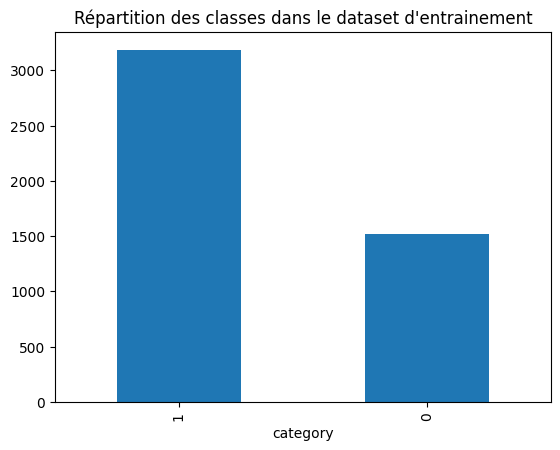

In [20]:
# is the dataset balanced?
total_train_df['category'].value_counts().plot(kind='bar', title='Répartition des classes dans le dataset d\'entrainement')

<Axes: title={'center': 'Répartition des classes dans le dataset de test'}, xlabel='category'>

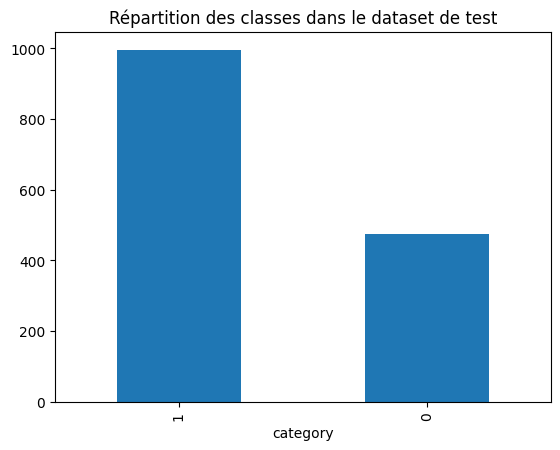

In [21]:
test_df['category'].value_counts().plot(kind='bar', title='Répartition des classes dans le dataset de test')

Le jeu de données présente un déséquilibre naturel entre les classes (avec une proportion plus importante de chiens que de chats), mais cela n'a pas impacté négativement les performances des modèles développés.

### **Répartition sur tout le dataset**

Tout le dataset = `list.txt`

Analyse du fichier list.txt du dataset et extrait les informations sur les images(classe, espace, race etc)

In [22]:
import re

def parse_list_file(file_path):
    """
    Lit le fichier list.txt du dataset Oxford-IIIT Pet
    Format des lignes : Image_Name CLASS-ID SPECIES BREED-ID
    
    Returns:
        pd.DataFrame avec colonnes: filename, breed, class_id, species, species_name, breed_id
    """
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Ignorer les commentaires qui commencent par #
            if line.startswith('#'):
                continue
            
            parts = line.strip().split()
            if len(parts) != 4:
                continue
            
            image_name = parts[0]
            class_id = int(parts[1])
            species_id = int(parts[2])
            breed_id = int(parts[3])
            
            # Extraire le nom de la race (tout avant le dernier underscore + chiffre)
            # On utilise une regex pour trouver le pattern: texte_chiffre(s) à la fin
            match = re.match(r'(.+)_\d+$', image_name)
            if match:
                breed_name = match.group(1)
            else:
                breed_name = image_name
            
            # Nom de l'espèce
            species_name = 'Cat' if species_id == 1 else 'Dog'
            
            # Catégorie pour cohérence avec le code précédent (0=Chat, 1=Chien)
            category = 0 if species_id == 1 else 1
            
            data.append({
                'filename': image_name + '.jpg',
                'breed': breed_name,
                'class_id': class_id,
                'species_id': species_id,
                'species_name': species_name,
                'category': str(category),
                'breed_id': breed_id
            })
    
    return pd.DataFrame(data)

# Charger le dataset complet
full_dataset_df = parse_list_file(annotations_folder + 'list.txt')

print(f"Dataset complet: {len(full_dataset_df)} images")
print(f"\nNombre de races: {full_dataset_df['breed'].nunique()}")
print(f"Nombre de classes: {full_dataset_df['class_id'].nunique()}")
print(f"\nPremières lignes:")
print(full_dataset_df.head(10))

Dataset complet: 7349 images

Nombre de races: 37
Nombre de classes: 37

Premières lignes:
             filename       breed  class_id  species_id species_name category  \
0  Abyssinian_100.jpg  Abyssinian         1           1          Cat        0   
1  Abyssinian_101.jpg  Abyssinian         1           1          Cat        0   
2  Abyssinian_102.jpg  Abyssinian         1           1          Cat        0   
3  Abyssinian_103.jpg  Abyssinian         1           1          Cat        0   
4  Abyssinian_104.jpg  Abyssinian         1           1          Cat        0   
5  Abyssinian_105.jpg  Abyssinian         1           1          Cat        0   
6  Abyssinian_106.jpg  Abyssinian         1           1          Cat        0   
7  Abyssinian_107.jpg  Abyssinian         1           1          Cat        0   
8  Abyssinian_108.jpg  Abyssinian         1           1          Cat        0   
9  Abyssinian_109.jpg  Abyssinian         1           1          Cat        0   

   breed_id  
0  

RÉPARTITION PAR ESPÈCE
species_name
Dog    4978
Cat    2371
Name: count, dtype: int64

Proportion:
species_name
Dog    67.737107
Cat    32.262893
Name: count, dtype: float64


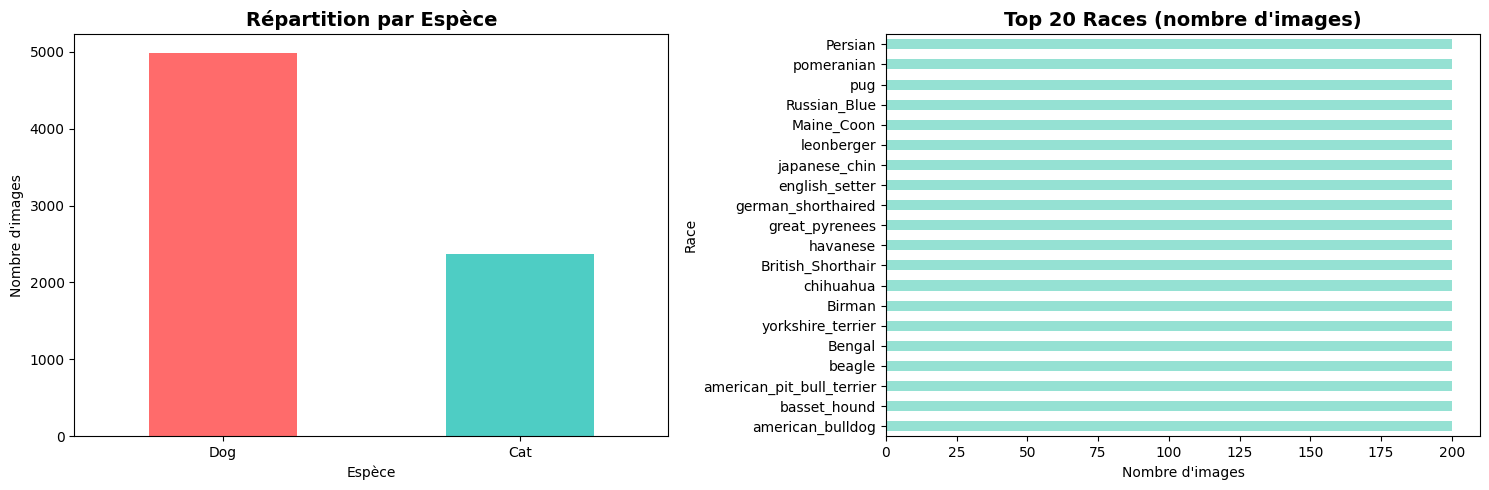

In [23]:
import matplotlib.pyplot as plt

# Répartition par espèce
print("=" * 50)
print("RÉPARTITION PAR ESPÈCE")
print("=" * 50)
species_counts = full_dataset_df['species_name'].value_counts()
print(species_counts)
print(f"\nProportion:")
print(species_counts / len(full_dataset_df) * 100)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1: Répartition par espèce
species_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Répartition par Espèce', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Espèce')
axes[0].set_ylabel('Nombre d\'images')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Graphique 2: Répartition par race (top 20)
breed_counts = full_dataset_df['breed'].value_counts().head(20)
breed_counts.plot(kind='barh', ax=axes[1], color='#95E1D3')
axes[1].set_title('Top 20 Races (nombre d\'images)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre d\'images')
axes[1].set_ylabel('Race')

plt.tight_layout()
plt.show()

In [15]:
# Statistiques détaillées par race
print("=" * 50)
print("RÉPARTITION PAR RACE")
print("=" * 50)

breed_stats = full_dataset_df.groupby(['breed', 'species_name']).size().reset_index(name='count')
breed_stats = breed_stats.sort_values('count', ascending=False)

print(f"\nNombre total de races: {len(breed_stats)}")
print(f"  - Races de chats: {len(breed_stats[breed_stats['species_name'] == 'Cat'])}")
print(f"  - Races de chiens: {len(breed_stats[breed_stats['species_name'] == 'Dog'])}")

print(f"\nStatistiques du nombre d'images par race:")
print(f"  - Minimum: {breed_stats['count'].min()}")
print(f"  - Maximum: {breed_stats['count'].max()}")
print(f"  - Moyenne: {breed_stats['count'].mean():.2f}")
print(f"  - Médiane: {breed_stats['count'].median():.2f}")

print(f"\nToutes les races avec leur nombre d'images:")
print(breed_stats.to_string(index=False))

RÉPARTITION PAR RACE

Nombre total de races: 37
  - Races de chats: 12
  - Races de chiens: 25

Statistiques du nombre d'images par race:
  - Minimum: 184
  - Maximum: 200
  - Moyenne: 198.62
  - Médiane: 200.00

Toutes les races avec leur nombre d'images:
                     breed species_name  count
                    Bengal          Cat    200
         British_Shorthair          Cat    200
                    Birman          Cat    200
                   Persian          Cat    200
                Maine_Coon          Cat    200
         yorkshire_terrier          Dog    200
           wheaten_terrier          Dog    200
                   Ragdoll          Cat    200
              Russian_Blue          Cat    200
          american_bulldog          Dog    200
                    Sphynx          Cat    200
              basset_hound          Dog    200
 american_pit_bull_terrier          Dog    200
        german_shorthaired          Dog    200
            english_setter          Do

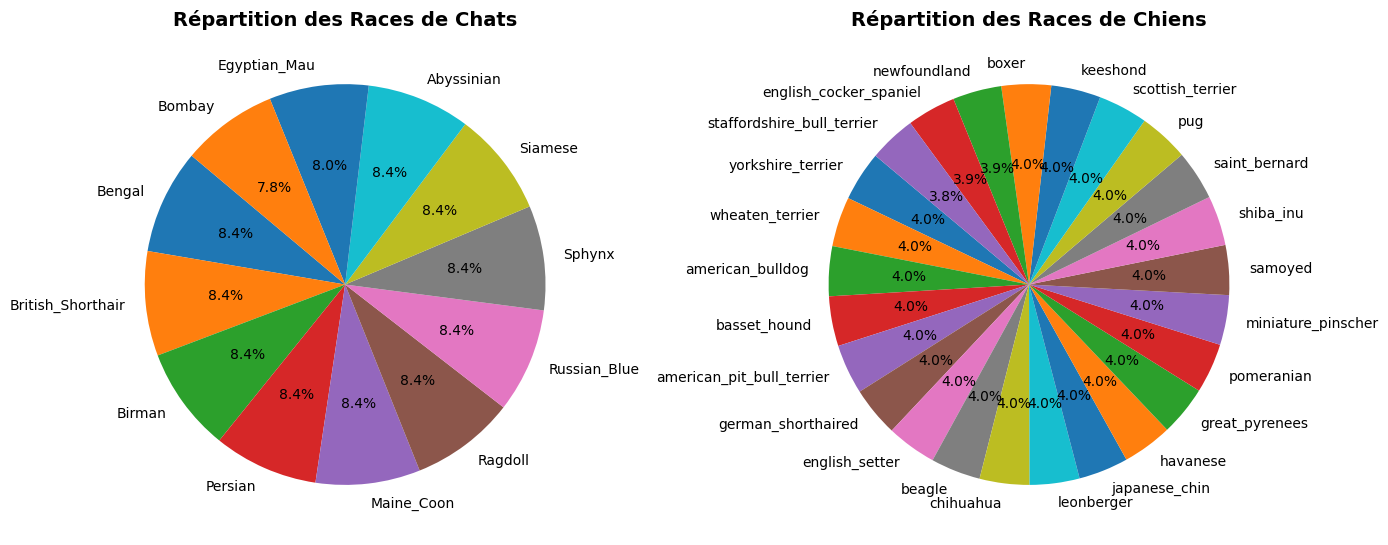

In [17]:
#plot the races of dogs and cats in two different plots in a a pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
# Races de chats
cat_breeds = breed_stats[breed_stats['species_name'] == 'Cat']
cat_breeds.set_index('breed')['count'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=140, legend=False)
axes[0].set_title('Répartition des Races de Chats', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')
# Races de chiens
dog_breeds = breed_stats[breed_stats['species_name'] == 'Dog']
dog_breeds.set_index('breed')['count'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140, legend=False)
axes[1].set_title('Répartition des Races de Chiens', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


La répartition quand à elle des races pour chaque espèce (chat ou chien ) est quasi équitable

### **Vérification de la cohérence et qualité des masques de segmentation**

In [18]:
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def parse_xml_annotation(xml_path):
    """
    Parse un fichier XML pour extraire les informations de bounding box
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Extraire les informations de l'image
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    # Extraire la bounding box
    obj = root.find('object')
    bbox = obj.find('bndbox')
    
    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)
    
    filename = root.find('filename').text
    animal_name = obj.find('name').text
    
    return {
        'filename': filename,
        'animal': animal_name,
        'width': width,
        'height': height,
        'bbox': (xmin, ymin, xmax, ymax)
    }

def load_trimap(trimap_path):
    """
    Charge un masque trimap
    Valeurs: 1=Foreground (animal), 2=Background, 3=Not classified (contour)
    """
    return Image.open(trimap_path)

# Vérification automatique: Comparer les dimensions et vérifier l'existence des fichiers
print("=" * 60)
print("VÉRIFICATION AUTOMATIQUE DE LA COHÉRENCE")
print("=" * 60)

xmls_folder = annotations_folder + 'xmls/'
trimaps_folder = annotations_folder + 'trimaps/'

# Prendre un échantillon d'images pour vérifier
sample_images = full_dataset_df.sample(n=100, random_state=42)

issues = []
for idx, row in sample_images.iterrows():
    image_name = row['filename'].replace('.jpg', '')
    
    xml_path = xmls_folder + image_name + '.xml'
    trimap_path = trimaps_folder + image_name + '.png'
    image_path = images_folder + row['filename']
    
    # Vérifier l'existence des fichiers
    xml_exists = os.path.exists(xml_path)
    trimap_exists = os.path.exists(trimap_path)
    image_exists = os.path.exists(image_path)
    
    if not xml_exists:
        issues.append(f"XML manquant: {image_name}")
    if not trimap_exists:
        issues.append(f"Trimap manquant: {image_name}")
    if not image_exists:
        issues.append(f"Image manquante: {image_name}")
    
    # Si tous les fichiers existent, vérifier la cohérence des dimensions
    if xml_exists and trimap_exists and image_exists:
        try:
            xml_info = parse_xml_annotation(xml_path)
            trimap = load_trimap(trimap_path)
            image = Image.open(image_path)
            
            # Vérifier que les dimensions correspondent
            if xml_info['width'] != image.width or xml_info['height'] != image.height:
                issues.append(f"Dimensions XML ≠ Image pour {image_name}")
            
            if trimap.size != image.size:
                issues.append(f"Dimensions Trimap ≠ Image pour {image_name}")
                
        except Exception as e:
            issues.append(f"Erreur lors du traitement de {image_name}: {str(e)}")

print(f"\nÉchantillon vérifié: {len(sample_images)} images")
print(f"Nombre de problèmes détectés: {len(issues)}")

if issues:
    print("\nProblèmes détectés:")
    for issue in issues[:10]:  # Afficher les 10 premiers
        print(f"  - {issue}")
    if len(issues) > 10:
        print(f"  ... et {len(issues) - 10} autres problèmes")
else:
    print("\n✓ Aucun problème détecté! Tous les fichiers sont cohérents.")

# Sauvegarder les issues dans un fichier texte
with open('data/coherence_issues.txt', 'w') as f:
    for issue in issues:
        f.write(issue + '\n')

VÉRIFICATION AUTOMATIQUE DE LA COHÉRENCE

Échantillon vérifié: 100 images
Nombre de problèmes détectés: 44

Problèmes détectés:
  - XML manquant: great_pyrenees_31
  - XML manquant: great_pyrenees_26
  - XML manquant: leonberger_198
  - XML manquant: basset_hound_26
  - XML manquant: japanese_chin_24
  - XML manquant: Birman_61
  - XML manquant: British_Shorthair_30
  - XML manquant: american_pit_bull_terrier_56
  - XML manquant: Maine_Coon_55
  - XML manquant: pug_87
  ... et 34 autres problèmes


Dans ce code, 100 images ont été sélectionnées aléatoirement pour la vérification de la cohérence des fichiers. 44 problèmes ont été identifiés, soit 44 % des images de l'échantillon. Les types de problèmes détectés sont principalement des fichiers XML dont les annotations des bounding boxes sont manquantes. On résoud ce problème de la manière suivante : 

- Si on fait de la **segmentation** : Le problème ne s'applique pas
- Si on fait de la **detection d'objet** : on aura besoin des bouding boxes donc on écarte les images problématiques 

In [13]:
# Analyse des valeurs dans les trimaps
print("\n" + "=" * 60)
print("ANALYSE DES MASQUES TRIMAP")
print("=" * 60)

# Charger quelques trimaps pour analyser la distribution des valeurs
sample_trimaps = []
for i in range(10):
    row = full_dataset_df.iloc[i]
    image_name = row['filename'].replace('.jpg', '')
    trimap_path = trimaps_folder + image_name + '.png'
    
    if os.path.exists(trimap_path):
        trimap = np.array(load_trimap(trimap_path))
        sample_trimaps.append(trimap)

if sample_trimaps:
    # Analyser les valeurs uniques
    all_values = set()
    for trimap in sample_trimaps:
        all_values.update(np.unique(trimap))
    
    print(f"\nValeurs trouvées dans les trimaps: {sorted(all_values)}")
    print(f"  1 = Foreground (Animal)")
    print(f"  2 = Background (Fond)")
    print(f"  3 = Not classified (Zone d'incertitude entre les deux, i.e zone de contour)")
    
    # Statistiques moyennes
    fg_percentages = []
    bg_percentages = []
    nc_percentages = []
    
    for trimap in sample_trimaps:
        total_pixels = trimap.size
        fg_percentages.append(np.sum(trimap == 1) / total_pixels * 100)
        bg_percentages.append(np.sum(trimap == 2) / total_pixels * 100)
        nc_percentages.append(np.sum(trimap == 3) / total_pixels * 100)
    
    print(f"\nStatistiques moyennes sur {len(sample_trimaps)} masques:")
    print(f"  Foreground (Animal): {np.mean(fg_percentages):.2f}% ± {np.std(fg_percentages):.2f}% de l'image")
    print(f"  Background: {np.mean(bg_percentages):.2f}% ± {np.std(bg_percentages):.2f}% de l'image")
    print(f"  Not classified: {np.mean(nc_percentages):.2f}% ± {np.std(nc_percentages):.2f}% de l'image")


ANALYSE DES MASQUES TRIMAP

Valeurs trouvées dans les trimaps: [np.uint8(1), np.uint8(2), np.uint8(3)]
  1 = Foreground (Animal)
  2 = Background (Fond)
  3 = Not classified (Zone d'incertitude entre les deux, i.e zone de contour)

Statistiques moyennes sur 10 masques:
  Foreground (Animal): 26.75% ± 12.05% de l'image
  Background: 58.73% ± 13.93% de l'image
  Not classified: 14.52% ± 4.35% de l'image


In [14]:
import numpy as np

print("=" * 60)
print("VÉRIFICATION DE LA QUALITÉ INTERNE DES MASQUES (PIXELS)")
print("=" * 60)

anomalies_pixels = []

# On reprend  l'échantillon sample_images
for idx, row in sample_images.iterrows():
    image_name = row['filename'].replace('.jpg', '')
    trimap_path = trimaps_folder + image_name + '.png'
    
    if os.path.exists(trimap_path):
        # On ouvre l'image et on la transforme en tableau de nombres
        mask = Image.open(trimap_path)
        mask_array = np.array(mask)
        
        # On regarde quelles sont les valeurs uniques présentes
        valeurs_uniques = np.unique(mask_array)
        
        # Vérification : Est-ce qu'on a autre chose que 1, 2 ou 3 ?
        # On utilise set() pour comparer les ensembles mathématiques
        valeurs_trouvees = set(valeurs_uniques)
        valeurs_autorisees = {1, 2, 3}
        
        # S'il y a des valeurs interdites (ex: 0, 255...)
        if not valeurs_trouvees.issubset(valeurs_autorisees):
            anomalies_pixels.append(f"{image_name} : Valeurs suspectes {valeurs_uniques}")

if anomalies_pixels:
    print(f"Attention ! {len(anomalies_pixels)} masques ont des valeurs de pixels incorrectes :")
    for a in anomalies_pixels[:5]:
        print(" -", a)
else:
    print("✓ Qualité validée : Tous les masques vérifiés ne contiennent que les valeurs {1, 2, 3}.")

VÉRIFICATION DE LA QUALITÉ INTERNE DES MASQUES (PIXELS)
✓ Qualité validée : Tous les masques vérifiés ne contiennent que les valeurs {1, 2, 3}.


### **Affichage de quelques masques et bounding boxes**

Affichage d'exemples avec:
1. Image originale + Bounding Box (XML)
2. Image originale + Masque Trimap superposé (transparent)

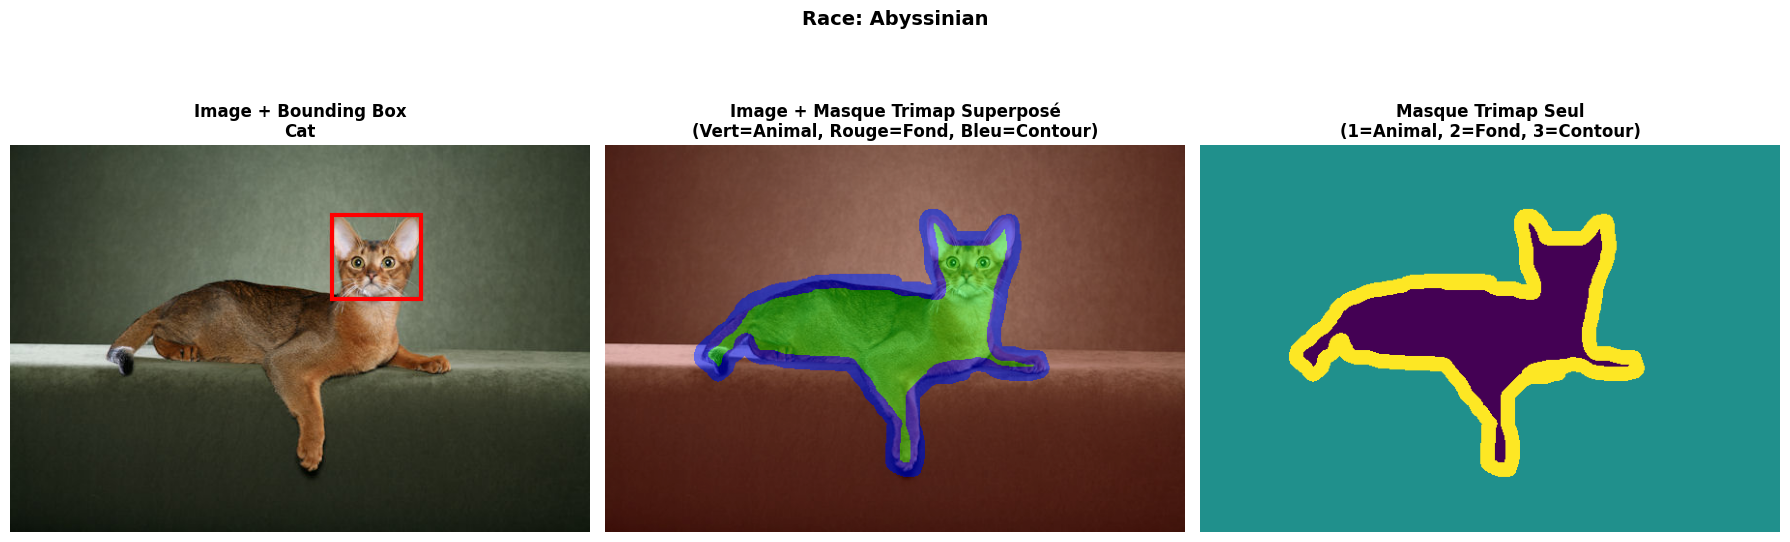


Statistiques pour Abyssinian_1:
  Dimensions: 600x400
  Bounding Box: (333, 72) -> (425, 158)
  Pixels Foreground (Animal): 22938 (9.56%)
  Pixels Background: 198766 (82.82%)
  Pixels Not Classified: 18296 (7.62%)
------------------------------------------------------------


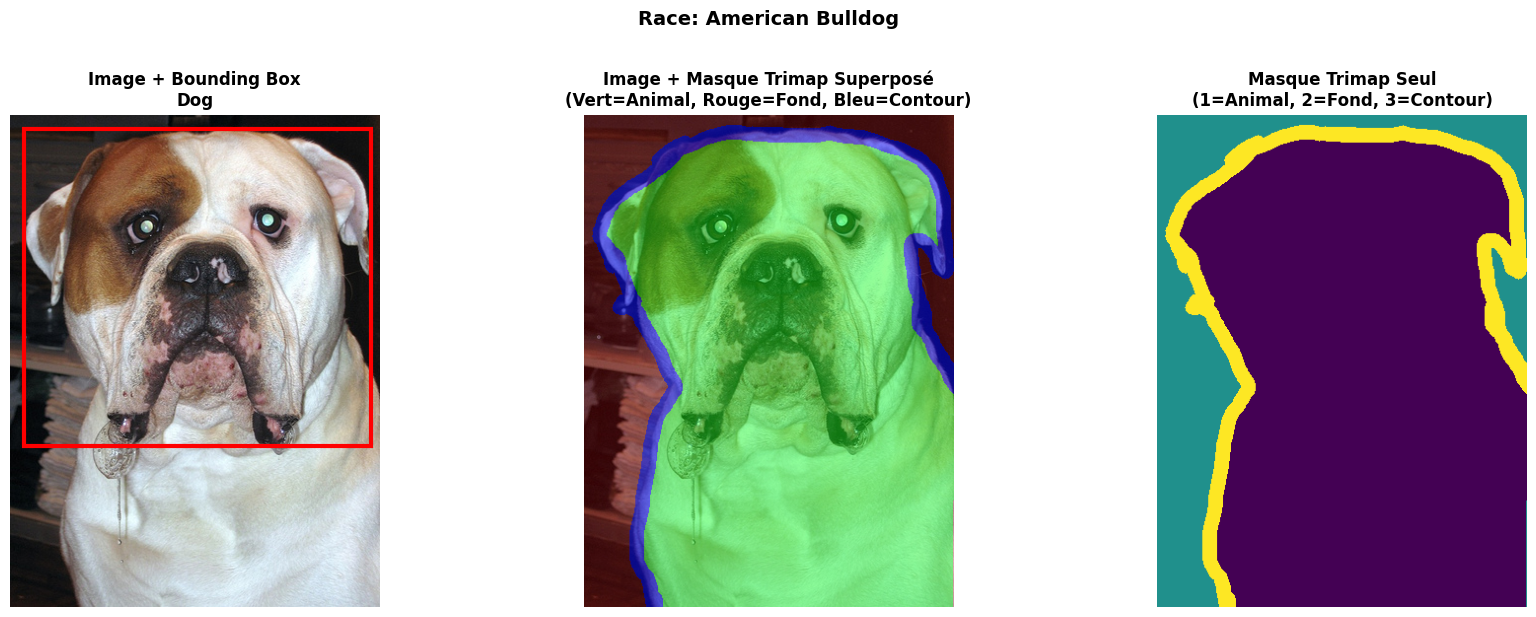


Statistiques pour american_bulldog_172:
  Dimensions: 375x500
  Bounding Box: (14, 14) -> (366, 336)
  Pixels Foreground (Animal): 135712 (72.38%)
  Pixels Background: 34674 (18.49%)
  Pixels Not Classified: 17114 (9.13%)
------------------------------------------------------------


In [25]:
def visualize_annotation(image_name, show_breed=True):
    """
    Affiche une image avec sa bounding box et son masque trimap
    """
    # Chemins des fichiers
    xml_path = xmls_folder + image_name + '.xml'
    trimap_path = trimaps_folder + image_name + '.png'
    image_path = images_folder + image_name + '.jpg'
    
    # Vérifier l'existence
    if not all([os.path.exists(p) for p in [xml_path, trimap_path, image_path]]):
        print(f"Fichiers manquants pour {image_name}")
        return
    
    # Charger les données
    xml_info = parse_xml_annotation(xml_path)
    image = Image.open(image_path)
    trimap = np.array(load_trimap(trimap_path))
    
    # Créer la figure avec 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Image originale avec Bounding Box
    axes[0].imshow(image)
    xmin, ymin, xmax, ymax = xml_info['bbox']
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=3, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f'Image + Bounding Box\n{xml_info["animal"].capitalize()}', 
                     fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # 2. Image originale avec masque trimap superposé (transparent)
    axes[1].imshow(image)
    
    # Créer un masque coloré
    # 1 = Foreground (vert), 2 = Background (rouge), 3 = Not classified (bleu)
    mask_colored = np.zeros((*trimap.shape, 4))
    mask_colored[trimap == 1] = [0, 1, 0, 0.4]  # Vert transparent pour l'animal
    mask_colored[trimap == 2] = [1, 0, 0, 0.2]  # Rouge transparent pour le fond
    mask_colored[trimap == 3] = [0, 0, 1, 0.5]  # Bleu transparent pour incertain
    
    axes[1].imshow(mask_colored)
    axes[1].set_title('Image + Masque Trimap Superposé\n(Vert=Animal, Rouge=Fond, Bleu=Contour)', 
                     fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # 3. Masque seul
    axes[2].imshow(trimap, cmap='viridis')
    axes[2].set_title('Masque Trimap Seul\n(1=Animal, 2=Fond, 3=Contour)', 
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    # Titre général
    if show_breed:
        breed = image_name.rsplit('_', 1)[0]
        fig.suptitle(f'Race: {breed.replace("_", " ").title()}', 
                    fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les stats
    total_pixels = trimap.size
    print(f"\nStatistiques pour {image_name}:")
    print(f"  Dimensions: {image.width}x{image.height}")
    print(f"  Bounding Box: ({xmin}, {ymin}) -> ({xmax}, {ymax})")
    print(f"  Pixels Foreground (Animal): {np.sum(trimap == 1)} ({np.sum(trimap == 1)/total_pixels*100:.2f}%)")
    print(f"  Pixels Background: {np.sum(trimap == 2)} ({np.sum(trimap == 2)/total_pixels*100:.2f}%)")
    print(f"  Pixels Not Classified: {np.sum(trimap == 3)} ({np.sum(trimap == 3)/total_pixels*100:.2f}%)")
    print("-" * 60)

# Exemples de visualisation
# Choisir quelques images intéressantes (chat et chien)
examples = [
    'Abyssinian_1',      # Chat
    'american_bulldog_172',  # Chien
]


for example in examples:
    visualize_annotation(example)


EXEMPLES ALÉATOIRES SUPPLÉMENTAIRES

 EXEMPLES DE CHATS:


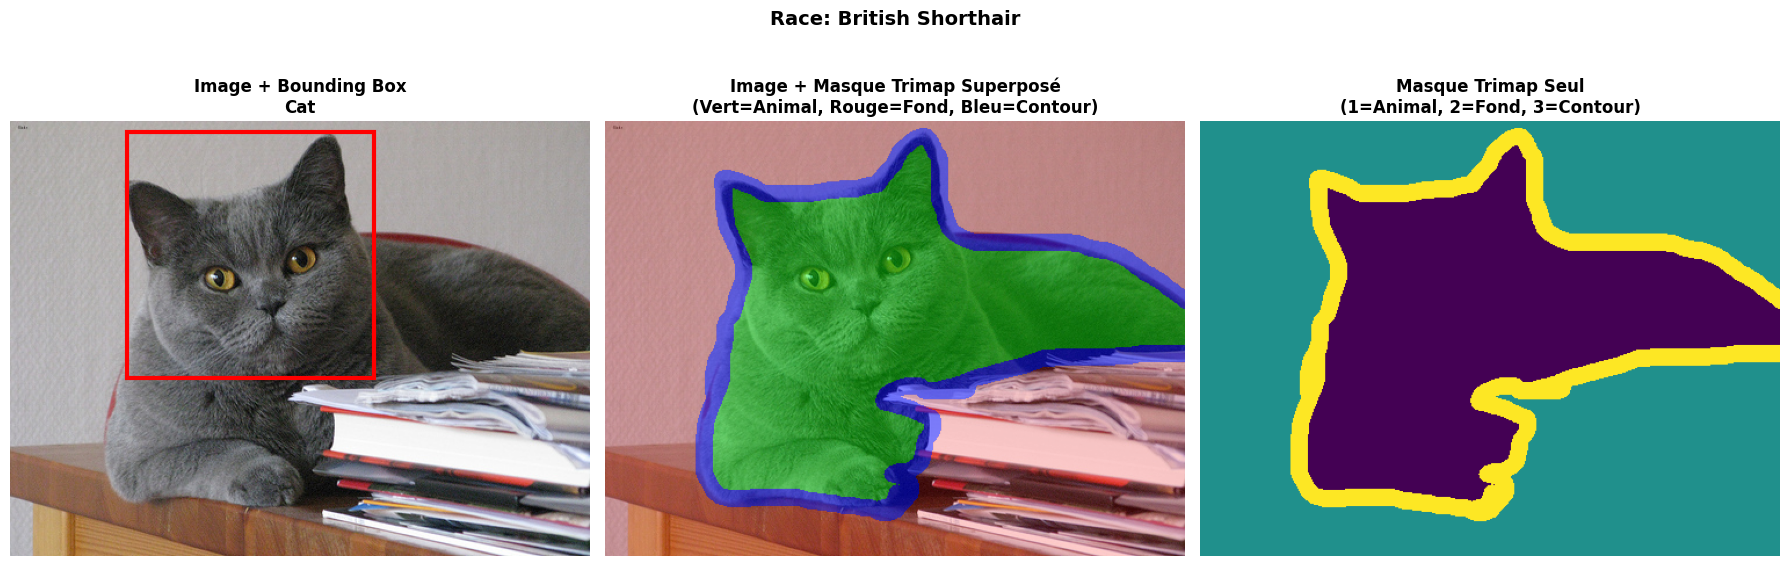


Statistiques pour British_Shorthair_199:
  Dimensions: 500x375
  Bounding Box: (100, 9) -> (313, 221)
  Pixels Foreground (Animal): 60473 (32.25%)
  Pixels Background: 106484 (56.79%)
  Pixels Not Classified: 20543 (10.96%)
------------------------------------------------------------
Fichiers manquants pour British_Shorthair_31


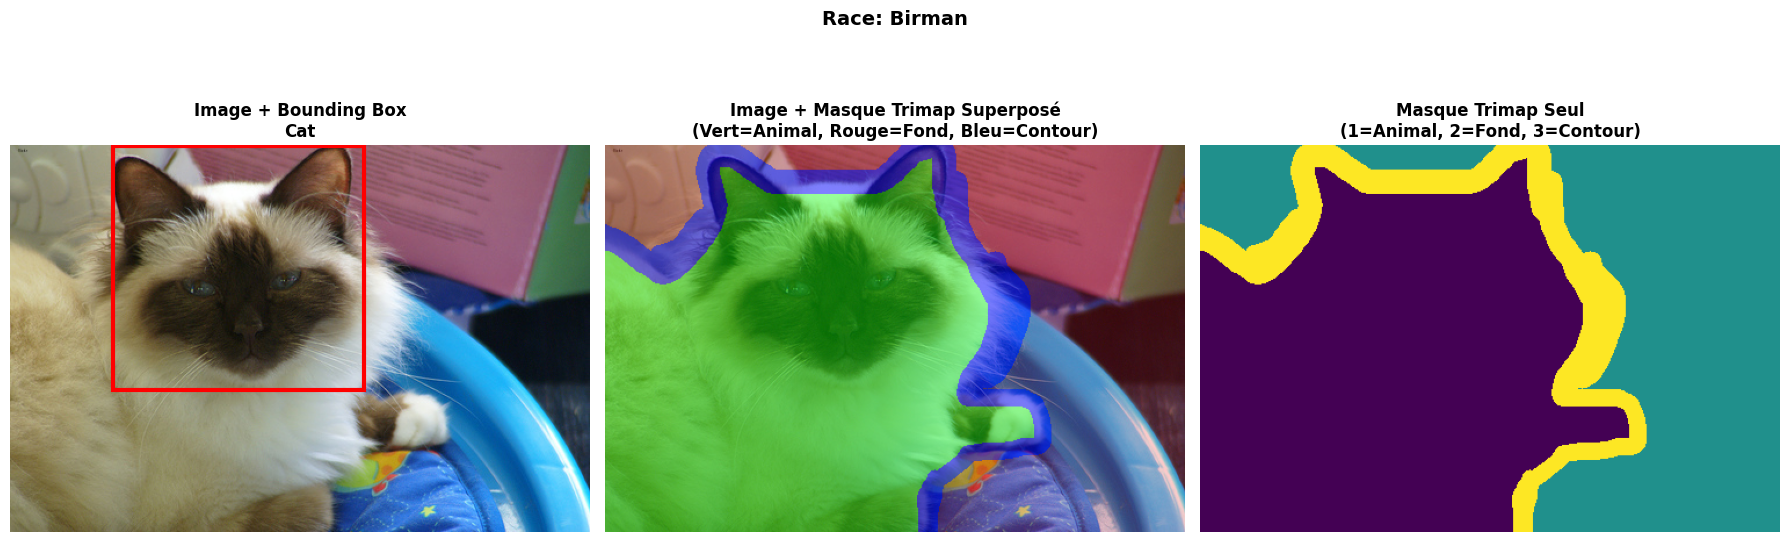


Statistiques pour Birman_100:
  Dimensions: 500x334
  Bounding Box: (88, 1) -> (305, 211)
  Pixels Foreground (Animal): 84723 (50.73%)
  Pixels Background: 63279 (37.89%)
  Pixels Not Classified: 18998 (11.38%)
------------------------------------------------------------

 EXEMPLES DE CHIENS:
Fichiers manquants pour newfoundland_193


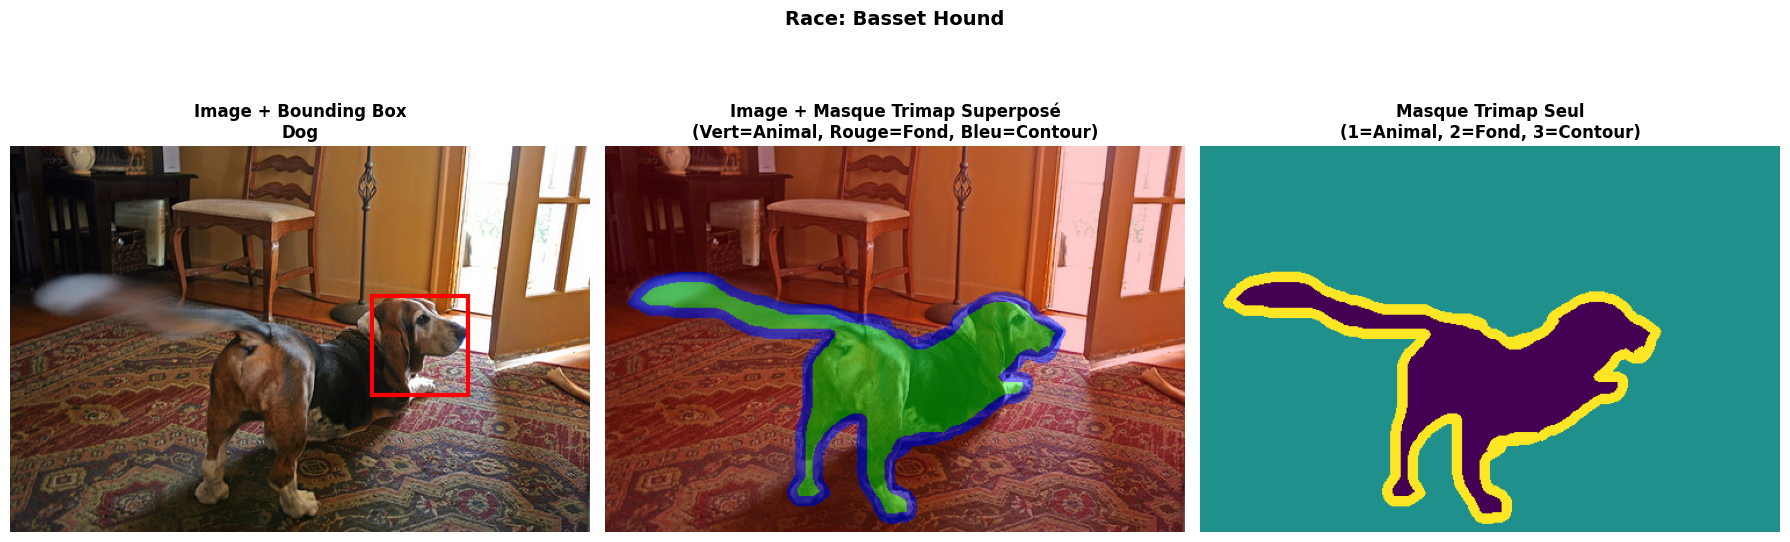


Statistiques pour basset_hound_140:
  Dimensions: 500x333
  Bounding Box: (312, 129) -> (394, 214)
  Pixels Foreground (Animal): 19395 (11.65%)
  Pixels Background: 135865 (81.60%)
  Pixels Not Classified: 11240 (6.75%)
------------------------------------------------------------
Fichiers manquants pour chihuahua_74


In [26]:
# Visualiser des exemples aléatoires pour une vérification plus complète
print("\n" + "=" * 60)
print("EXEMPLES ALÉATOIRES SUPPLÉMENTAIRES")
print("=" * 60)

# Prendre 3 chats et 3 chiens au hasard
random_cats = full_dataset_df[full_dataset_df['species_name'] == 'Cat'].sample(n=3, random_state=42)
random_dogs = full_dataset_df[full_dataset_df['species_name'] == 'Dog'].sample(n=3, random_state=42)

print("\n EXEMPLES DE CHATS:")
for _, row in random_cats.iterrows():
    image_name = row['filename'].replace('.jpg', '')
    visualize_annotation(image_name)

print("\n EXEMPLES DE CHIENS:")
for _, row in random_dogs.iterrows():
    image_name = row['filename'].replace('.jpg', '')
    visualize_annotation(image_name)

# **Classification binaire**

Cette partie affiche les courbes de loss et compare les performances des modèles de classification binaire préalablement entrainées. Les résultats ont étés sauvegardés dans `models/temp_results/classification`.

On considère ici 4 modèles: 
- CNN simple composé de 4 blocks de convolution 3*3
- CNN simple avec data augmentation
- VGG transfert learning: le CNN profond pré-entrainé VGG16 auquel on a ajouté une tête de classification
- VGG finetuned: VGG transfert learning avec les 3 dernier paramètre de VGG 16 dégelés, les poids sont recalculés pour ce modèle. 

In [ ]:
# 1. Importer les bibliothèques nécessaires
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

### Charger les courbes de loss sauvegardées
On charge les fichiers .npy ou .pt contenant les courbes de loss pour chaque modèle.

In [ ]:
# 2. Charger les courbes de loss sauvegardées
results_dir = 'models/temp_results/classification'

model_names = {
    'cnn': 'cnn',
    'cnn_aug': 'cnn_data_augmentation',
    'vgg_full_finetune': 'vgg_full_finetune',
    'vgg_transfer': 'vgg_transferlearning'
}

loss_logs = {}
for key, subdir in model_names.items():
    path = os.path.join(results_dir, subdir, 'loss_log.npy')
    if os.path.exists(path):
        loss_logs[key] = np.load(path, allow_pickle=True).item()
    else:
        print(f"Fichier non trouvé pour {key}: {path}")

### Affichage des courbes de loss pour chaque modèle

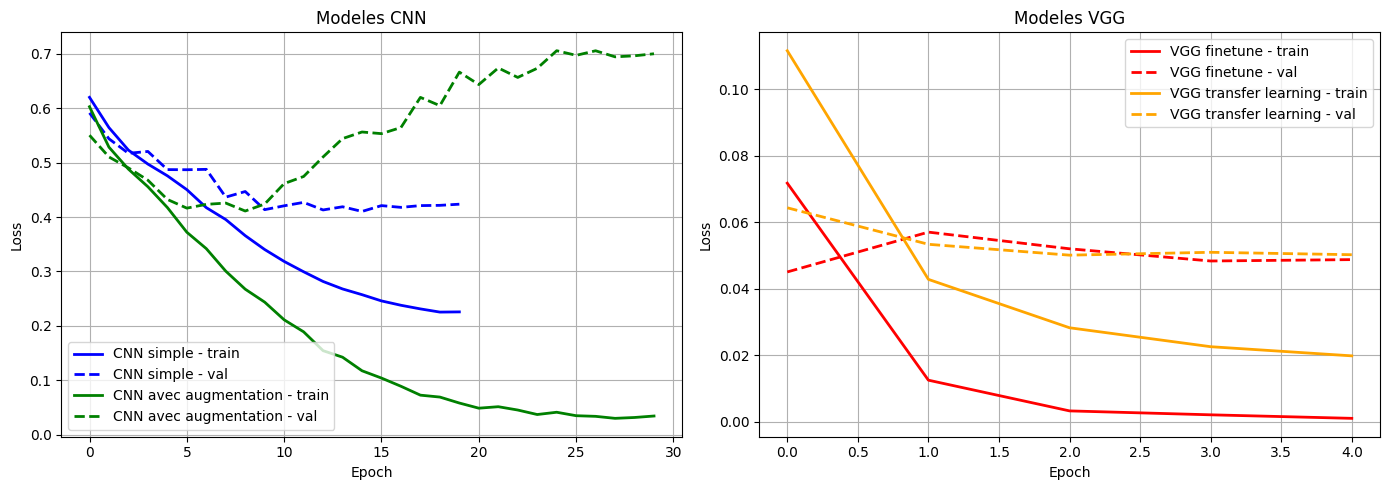

In [ ]:
# 3. Afficher les courbes de loss pour chaque modèle
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique CNN
cnn_models = {'cnn': 'CNN simple', 'cnn_aug': 'CNN avec augmentation'}
colors_cnn = ['blue', 'green']
for i, (key, label) in enumerate(cnn_models.items()):
    if key in loss_logs:
        log = loss_logs[key]
        ax1.plot(log['train'], label=f'{label} - train', color=colors_cnn[i], linewidth=2)
        ax1.plot(log['val'], label=f'{label} - val', color=colors_cnn[i], linestyle='--', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Modeles CNN')
ax1.legend()
ax1.grid(True)

# Graphique VGG
vgg_models = {'vgg_full_finetune': 'VGG finetune', 'vgg_transfer': 'VGG transfer learning'}
colors_vgg = ['red', 'orange']
for i, (key, label) in enumerate(vgg_models.items()):
    if key in loss_logs:
        log = loss_logs[key]
        ax2.plot(log['train'], label=f'{label} - train', color=colors_vgg[i], linewidth=2)
        ax2.plot(log['val'], label=f'{label} - val', color=colors_vgg[i], linestyle='--', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Modeles VGG')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



Les modèles VGG en transfer learning et en finetune donnent d’excellents résultats sans overfitting. Le CNN sans data augmentation fonctionne correctement, mais avec data augmentation, on observe de l’overfitting. Ce résultat est surprenant : une explication possible est que les transformations appliquées sont trop fortes ou inadaptées, ce qui rend les images du train trop différentes de la distribution réelle. Le modèle a alors du mal à généraliser et sur-apprend les exemples du train, ce qui dégrade ses performances en validation.

### Comparaison des performances des modèles
On affiche la meilleure loss de validation atteinte pour chaque modèle dans un tableau récapitulatif.

              Modèle  Best Val Loss
2  vgg_full_finetune       0.045058
3       vgg_transfer       0.050105
0                cnn       0.410293
1            cnn_aug       0.411050


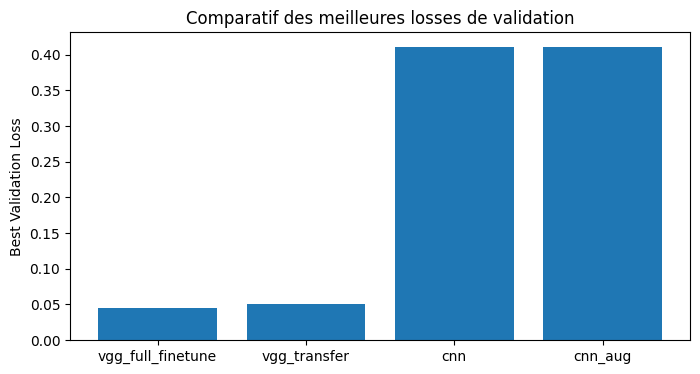

In [ ]:
# 4. Comparer les performances des modèles
import pandas as pd

perf = []
for key, log in loss_logs.items():
    best_val = np.min(log['val'])
    perf.append({'Modèle': key, 'Best Val Loss': best_val})

perf_df = pd.DataFrame(perf)
perf_df = perf_df.sort_values('Best Val Loss')
print(perf_df)

plt.figure(figsize=(8,4))
plt.bar(perf_df['Modèle'], perf_df['Best Val Loss'])
plt.ylabel('Best Validation Loss')
plt.title('Comparatif des meilleures losses de validation')
plt.show()

### Evaluation sur le test set
Ici tous les modèles ont été évalués sur les poids correspondant à la loss la plus faible sur la validation. 

In [ ]:
import torch.nn as nn
from dataloader_classification import get_oxford_loaders
from models.classification_binaire import ClassificationNetwork, MyVGGClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Charger les dataloaders
root_dir = './data/oxford-iiit-pet'
loaders = get_oxford_loaders(
    root_dir,
    task='classification',
    batch_size=16,
    dataset_variant='custom'
)
test_loader = loaders['test']

Device: cuda


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            
            # Pour classification binaire avec BCEWithLogitsLoss
            probs = torch.sigmoid(outputs.view(-1))
            preds = (probs > 0.5).long()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    
    # Calcul des metriques
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'F1 Score: {f1:.4f}')
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # ROC Curve
    ax1.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
    ax1.plot([0, 1], [0, 1], 'k--', label='Random')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend()
    ax1.grid(True)
    
    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    ax2.set_title('Confusion Matrix')
    
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'f1': f1, 'auc': roc_auc}

### Evaluation CNN simple

CNN simple
Accuracy: 0.8190
Precision: 0.8735
F1 Score: 0.8655


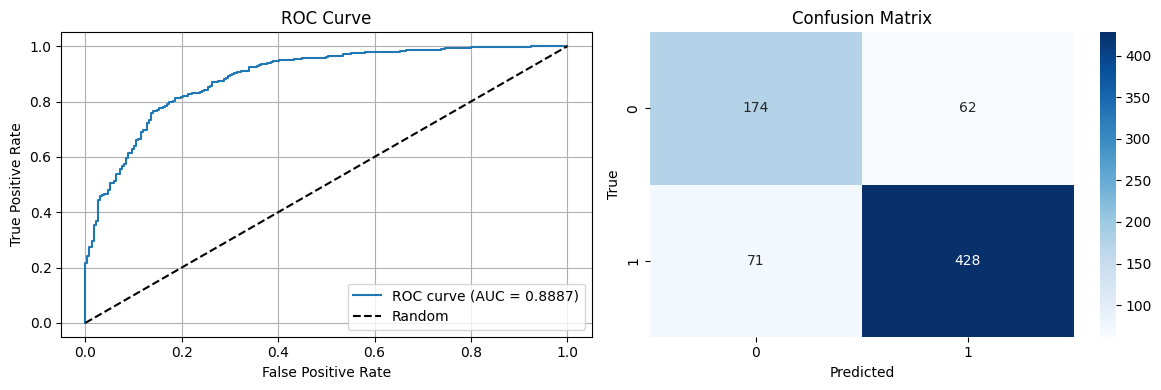

In [ ]:
print('CNN simple')
model_cnn = ClassificationNetwork().to(device)
model_cnn.load_state_dict(torch.load('models/temp_results/classification/cnn/best.pth', map_location=device))
results_cnn = evaluate_model(model_cnn, test_loader, device)

### Evaluation CNN avec data augmentation

CNN avec data augmentation
Accuracy: 0.8259
Precision: 0.8778
F1 Score: 0.8707


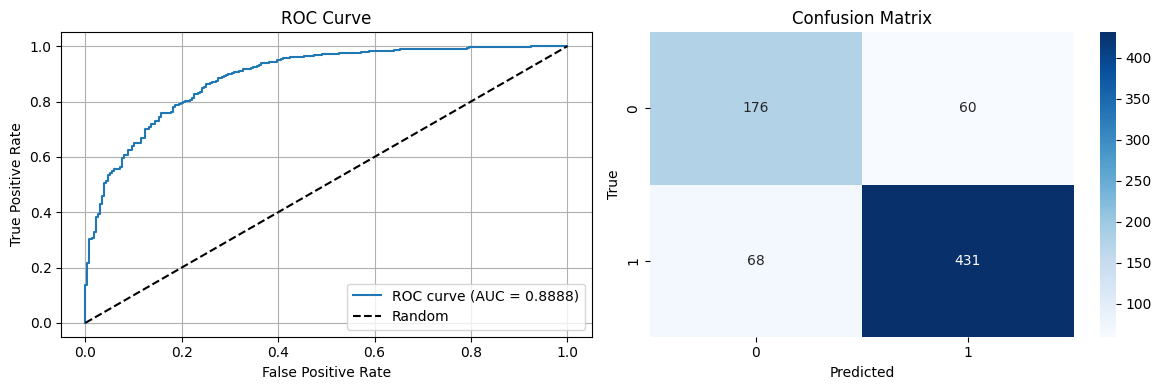

In [ ]:
print('CNN avec data augmentation')
model_cnn_aug = ClassificationNetwork().to(device)
model_cnn_aug.load_state_dict(torch.load('models/temp_results/classification/cnn_data_augmentation/best.pth', map_location=device))
results_cnn_aug = evaluate_model(model_cnn_aug, test_loader, device)

### Evaluation VGG full finetune

VGG full finetune
Accuracy: 0.9823
Precision: 0.9939
F1 Score: 0.9869


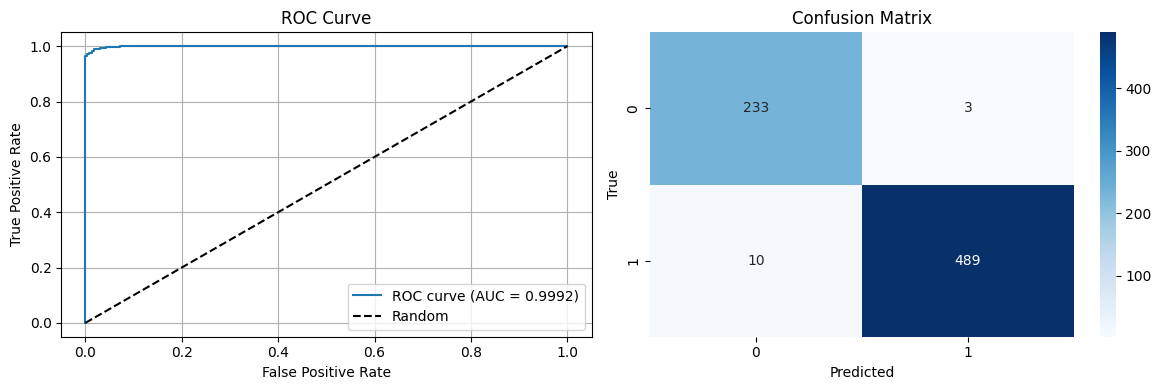

In [ ]:
print('VGG full finetune')
model_vgg_finetune = MyVGGClassifier(freeze_base=True, finetune=True).to(device)
model_vgg_finetune.load_state_dict(torch.load('models/temp_results/classification/vgg_full_finetune/best.pth', map_location=device))
results_vgg_finetune = evaluate_model(model_vgg_finetune, test_loader, device)

### Evaluation VGG transfer learning

VGG transfer learning
Accuracy: 0.9769
Precision: 0.9859
F1 Score: 0.9829


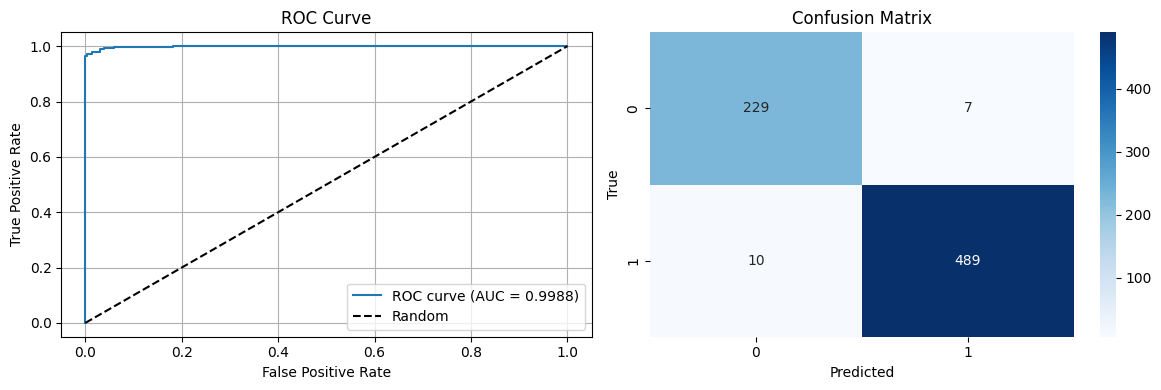

In [ ]:
print('VGG transfer learning')
model_vgg_transfer = MyVGGClassifier(freeze_base=False).to(device)
model_vgg_transfer.load_state_dict(torch.load('models/temp_results/classification/vgg_transferlearning/best.pth', map_location=device))
results_vgg_transfer = evaluate_model(model_vgg_transfer, test_loader, device)

Les courbes ROC des modèles VGG sont quasi parfaites, témoignant d’une excellente capacité de discrimination. Celles des CNN sont également très bonnes, indiquant de bonnes performances de classification.

### Tableau recapitulatif des metriques


Tableau recapitulatif des performances sur le test set:
                       accuracy  precision        f1       auc
VGG finetune           0.982313   0.993902  0.986882  0.999219
VGG transfer learning  0.976871   0.985887  0.982915  0.998760
CNN avec augmentation  0.825850   0.877800  0.870707  0.888769
CNN simple             0.819048   0.873469  0.865521  0.888710


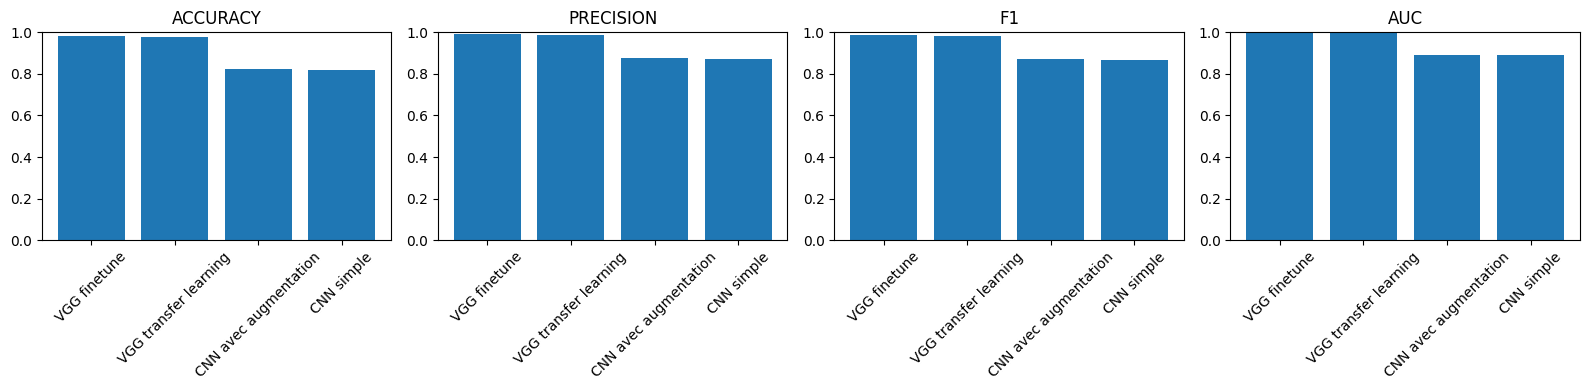

In [ ]:
all_results = {
    'CNN simple': results_cnn,
    'CNN avec augmentation': results_cnn_aug,
    'VGG finetune': results_vgg_finetune,
    'VGG transfer learning': results_vgg_transfer
}

results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('accuracy', ascending=False)
print('\nTableau recapitulatif des performances sur le test set:')
print(results_df)

# Graphique comparatif
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['accuracy', 'precision', 'f1', 'auc']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric])
    axes[i].set_title(metric.upper())
    axes[i].set_ylim([0, 1])
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Les modèles VGG (finetune et transfer learning) surpassent nettement les CNN, avec des scores d’accuracy, de précision, de F1 et d’AUC très élevés (tous >0.97).
Le VGG finetune, qui ajuste les 3 derniers paramètres du backbone, obtient les meilleurs résultats sur tous les indicateurs, légèrement devant le VGG transfer learning (où tous les paramètres du backbone sont gelés). Cela montre que permettre l’ajustement de quelques couches supplémentaires améliore la capacité du modèle à s’adapter à la tâche cible, ici classification binaire. 

Les deux CNN (avec et sans data augmentation) ont des performances similaires, nettement inférieures à celles des VGG, avec une accuracy autour de 0.82 et un AUC d’environ 0.89.
À noter : pour le CNN avec augmentation, les poids utilisés sont ceux correspondant à la meilleure loss de validation (avant overfitting), ce qui donne une vision optimiste de ses performances. Malgré cela, il reste en retrait par rapport aux VGG.

En résumé :
Les architectures VGG, même avec peu de fine-tuning, offrent une bien meilleure généralisation et capacité de discrimination que les CNN peu profonds que nous avons implémenté et entrainés.
Le fine-tuning partiel (3 couches) apporte un gain supplémentaire par rapport au simple transfert de features.
Les CNN restent limités sur ce jeu de données, même avec data augmentation.


# **Classification fine des races**

Dans cette partie, nous nous intéressons à la classification fine des 37 races de chiens et chats. Le modèle devra prédire à partir de l'image qu'on lui donne la race de chiens ou chats correspondante.

Nous testons des architectures CNN, à savoir une architecture "maison" puis un modèle ResNet50 pré-entraîné sur le dataset ImageNet. 

Nous entraînons notre modèle maison sur le dataset, tandis que nous utilisons du transfer learning pour calibrer ResNet50 à notre problème de classification.

La plan est le suivant : 
- Visualisations et comparaisons des losses
- Evaluations et comparaisons des accuracies
- Analyse des erreurs du meilleur modèle
- Interprétabilité avec Grad-CAM du meilleur modèle

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## **Présentation de notre modèle**
Ce modèle nous sert de baseline pour évaluer l'efficacité du transfer learning avec ResNet50.


Notre modèle suit une approche classique avec 4 blocs convolutionnels successifs :

#### **4 Blocs Convolutionnels**
- **Bloc 1** : `3 → 32 canaux`
- **Bloc 2** : `32 → 64 canaux`
- **Bloc 3** : `64 → 128 canaux`
- **Bloc 4** : `128 → 256 canaux`

Chaque bloc utilise la structure : `Conv2D (3×3) → BatchNorm → ReLU → MaxPool2D (2×2)`

#### **Tête de Classification**
- **Pooling Global** : Réduit chaque feature map 256×16×16 à 256×1×1
- **FC1** : `256 → 512` avec ReLU et Dropout (50%)
- **FC2** : `512 → 37 classes` (sortie finale)

In [ ]:
# Définition des chemins vers les résultats
results_paths = {
    'Baseline CNN': 'models/temp_results/classification_fine/baseline_simple_cnn',
    'Phase 1 (Head Only)': 'models/temp_results/classification_fine/phase1_head_only',
    'Phase 2 (Full Fine-tuning)': 'models/temp_results/classification_fine/phase2_full_finetuning'
}

# Chargement des loss logs
loss_data = {}
configs = {}

for name, path in results_paths.items():
    loss_path = Path(path) / 'loss_log.npy'
    config_path = Path(path) / 'config.yaml'
    
    if loss_path.exists():
        loss_data[name] = np.load(loss_path, allow_pickle=True).item()
    
    if config_path.exists():
        with open(config_path, 'r') as f:
            configs[name] = yaml.safe_load(f)

## **Méthodologie d'entraînement pour ResNet50 (Transfer Learning)**

Nous adoptons une stratégie en deux phases pour entraîner ResNet50 sur notre tâche de classification fine.
<div style="background-color: #d4edda; padding: 15px; border-left: 4px solid #28a745; margin: 15px 0;">
<h4><strong>Phase 1 (Head Fine-tuning)</strong></h4>
<ul>
    <li><strong>Objectif</strong> : Entraîner uniquement la tête de classification tout en gardant les poids pré-entraînés d'ImageNet fixes.</li>
    <li><strong>Avantage</strong> : Permet au modèle d'apprendre rapidement des caractéristiques spécifiques au dataset cible sans perturber les features générales déjà apprises.</li>
    <li><strong>Configuration</strong> : Taux d'apprentissage initial de 1e-3</li>
</ul>
</div>
<div style="background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0;">
<h4><strong>Phase 2 (Full Fine-tuning)</strong></h4>
<ul>
    <li><strong>Objectif</strong> : Affiner l'ensemble du modèle, y compris les couches convolutionnelles pré-entraînées.</li>
    <li><strong>Avantage</strong> : Permet au modèle d'ajuster les features générales aux spécificités du dataset cible, améliorant ainsi la performance.</li>
    <li><strong>Configuration</strong> : Taux d'apprentissage initial de 1e-4</li>
</ul>
</div>

## **Comparaison Train vs Validation**

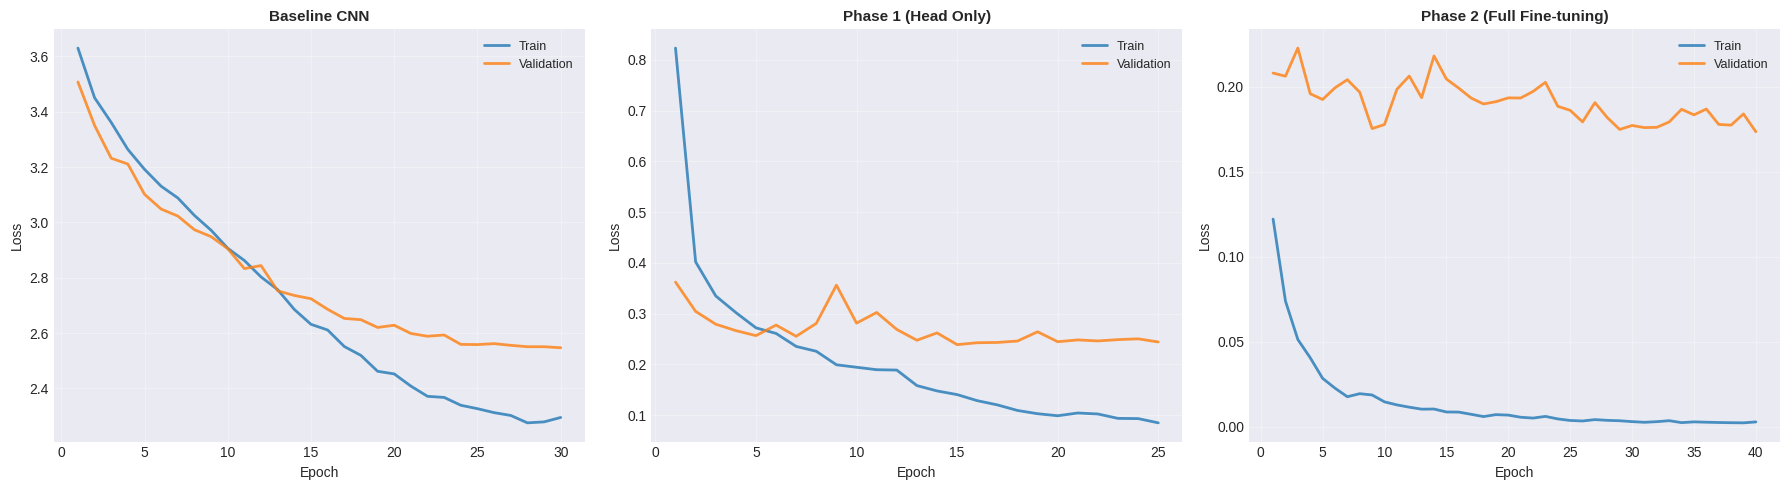

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(loss_data.items()):
    ax = axes[idx]
    
    if 'train' in data and 'val' in data:
        epochs = range(1, len(data['train']) + 1)
        ax.plot(epochs, data['train'], label='Train', linewidth=2, alpha=0.8)
        ax.plot(epochs, data['val'], label='Validation', linewidth=2, alpha=0.8)
        
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Évaluation des modèles sur le test set**

In [ ]:
import os
import sys
import torch
import torch.nn as nn
from dataloader_segmentation import get_oxford_loaders
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Importer les modèles depuis classification_models.py
sys.path.insert(0, 'models')
from classification_models import SimplePetCNN, ResNet50Pets

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<p>Les trois modèles présentent des comportements d'apprentissage distincts.</p>

<div style="background-color: #f8f9fa; padding: 15px; border-left: 4px solid #007bff; margin: 15px 0;">
<h4><strong>Baseline CNN</strong></h4>
<ul>
    <li><strong>Convergence lente</strong> : Les losses diminuent progressivement de ~3.6 à ~2.5</li>
    <li><strong>Gap train/validation modéré</strong> : Écart stable autour de 0.1-0.2, indiquant un léger overfitting</li>
    <li><strong>Plateau précoce</strong> : La validation stagne vers l'epoch 15, suggérant une capacité limitée</li>
</ul>
</div>

<div style="background-color: #e8f5e8; padding: 15px; border-left: 4px solid #28a745; margin: 15px 0;">
<h4><strong>Phase 1 (Head Only)</strong></h4>
<ul>
    <li><strong>Convergence rapide</strong> : Loss train chute drastiquement de 0.8 à ~0.1 en quelques epochs</li>
    <li><strong>Efficacité du transfer learning</strong> : Les features pré-entraînées ImageNet sont déjà pertinentes</li>
    <li><strong>Validation stable</strong> : Reste autour de 0.25-0.3, montrant une bonne généralisation</li>
</ul>
</div>

<div style="background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0;">
<h4><strong>Phase 2 (Full Fine-tuning)</strong></h4>
<ul>
    <li><strong>Performance optimale</strong> : Loss train descend proche de 0, validation vers 0.17, ce qui indique une très bonne performance malgré un léger overfitting</li>
</ul>
</div>

In [ ]:
def evaluate_model(model, test_loader, device):
    """Évalue un modèle sur le test set et retourne predictions et labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    accuracy = (all_preds == all_labels).mean() * 100.0
    
    return all_preds, all_labels, accuracy

In [ ]:
# Chargement et évaluation des modèles sauvegardés
model_results = {}

# Charger les loaders
loaders = get_oxford_loaders(
    root_dir='data/oxford-iiit-pet',
    task='classification_fine',
    batch_size=32
)
test_loader = loaders['test']

# Récupérer le mapping des labels
# Créer le mapping à partir des données du dataset
breed_to_label = {}
label_to_name = {}

# Parcourir le dataset pour extraire les breeds uniques
for idx in range(len(test_loader.dataset.df)):
    row = test_loader.dataset.df.iloc[idx]
    breed_name = row['breed']
    breed_id = row['breed_id']
    category = row['category']  # 0=Cat, 1=Dog
    
    # Calculer le label comme dans le dataset
    label = breed_id - 1 if category == 0 else 12 + breed_id - 1
    
    if label not in label_to_name:
        label_to_name[label] = breed_name
        breed_to_label[breed_name] = label

num_classes = len(label_to_name)

# 1. Baseline CNN
baseline_path = 'models/temp_results/classification_fine/baseline_simple_cnn/best.pth'
if os.path.exists(baseline_path):
    baseline_model = SimplePetCNN(num_classes=num_classes).to(DEVICE)
    baseline_model.load_state_dict(torch.load(baseline_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(baseline_model, test_loader, DEVICE)
    model_results['Baseline CNN'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }
else:
    print("  → Modèle Baseline CNN non trouvé")

# 2. Phase 1 (Head Only)
phase1_path = 'models/temp_results/classification_fine/phase1_head_only/best.pth'
if os.path.exists(phase1_path):
    phase1_model = ResNet50Pets(num_classes=num_classes).to(DEVICE)
    phase1_model.load_state_dict(torch.load(phase1_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(phase1_model, test_loader, DEVICE)
    model_results['Phase 1 (Head Only)'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }

# 3. Phase 2 (Full Fine-tuning)
phase2_path = 'models/temp_results/classification_fine/phase2_full_finetuning/best.pth'
if os.path.exists(phase2_path):
    phase2_model = ResNet50Pets(num_classes=num_classes).to(DEVICE)
    phase2_model.load_state_dict(torch.load(phase2_path, map_location=DEVICE))
    
    preds, labels, accuracy = evaluate_model(phase2_model, test_loader, DEVICE)
    model_results['Phase 2 (Full Fine-tuning)'] = {
        'predictions': preds,
        'labels': labels,
        'accuracy': accuracy,
        'label_to_name': label_to_name,
        'num_classes': num_classes
    }


## **Comparaison des Accuracies**

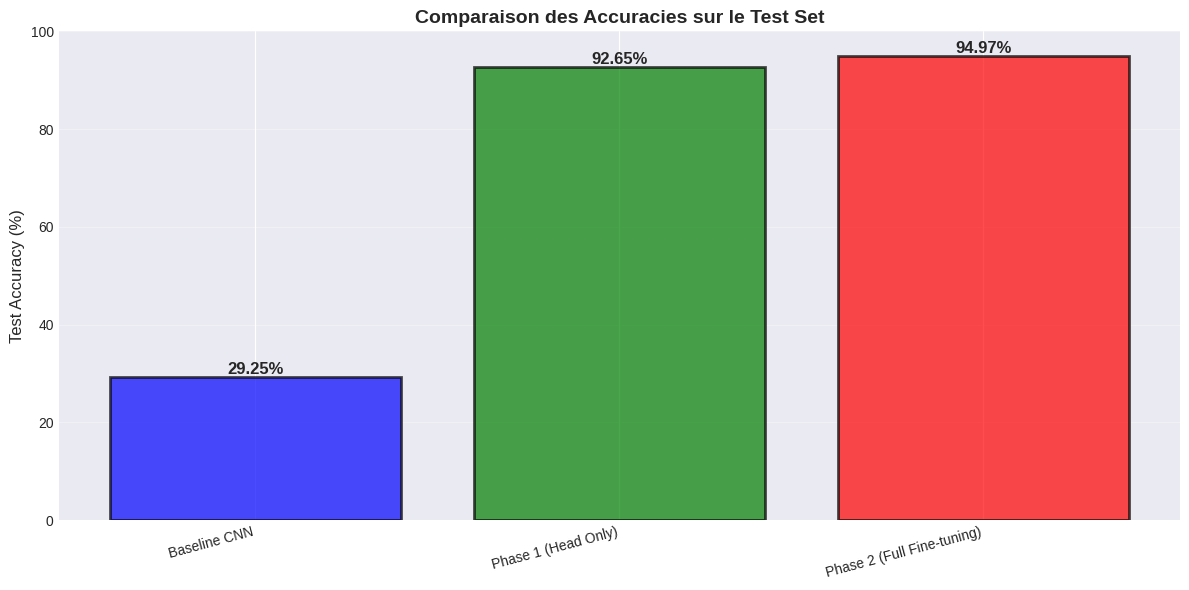

In [ ]:
# Graphique de comparaison des accuracies
fig, ax = plt.subplots(figsize=(12, 6))

model_names = list(model_results.keys())
accuracies = [model_results[name]['accuracy'] for name in model_names]

bars = ax.bar(model_names, accuracies, color=['blue', 'green', 'red'], alpha=0.7, edgecolor='black', linewidth=2)

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Comparaison des Accuracies sur le Test Set', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Comme on peut le voir, le modèle ResNet50 avec fine-tuning complet surpasse largement les autres modèles, atteignant une accuracy de 94.97%.**

**Le modèle avec seulement la tête fine-tunée atteint déjà une performance de 92.65%. En revanche, le modèle baseline CNN, entraîné from scratch, ne parvient qu'à une accuracy de 29.25%.**

## **Matrice de confusion du meilleur modèle (ResNet50 Full Fine-tuning)**

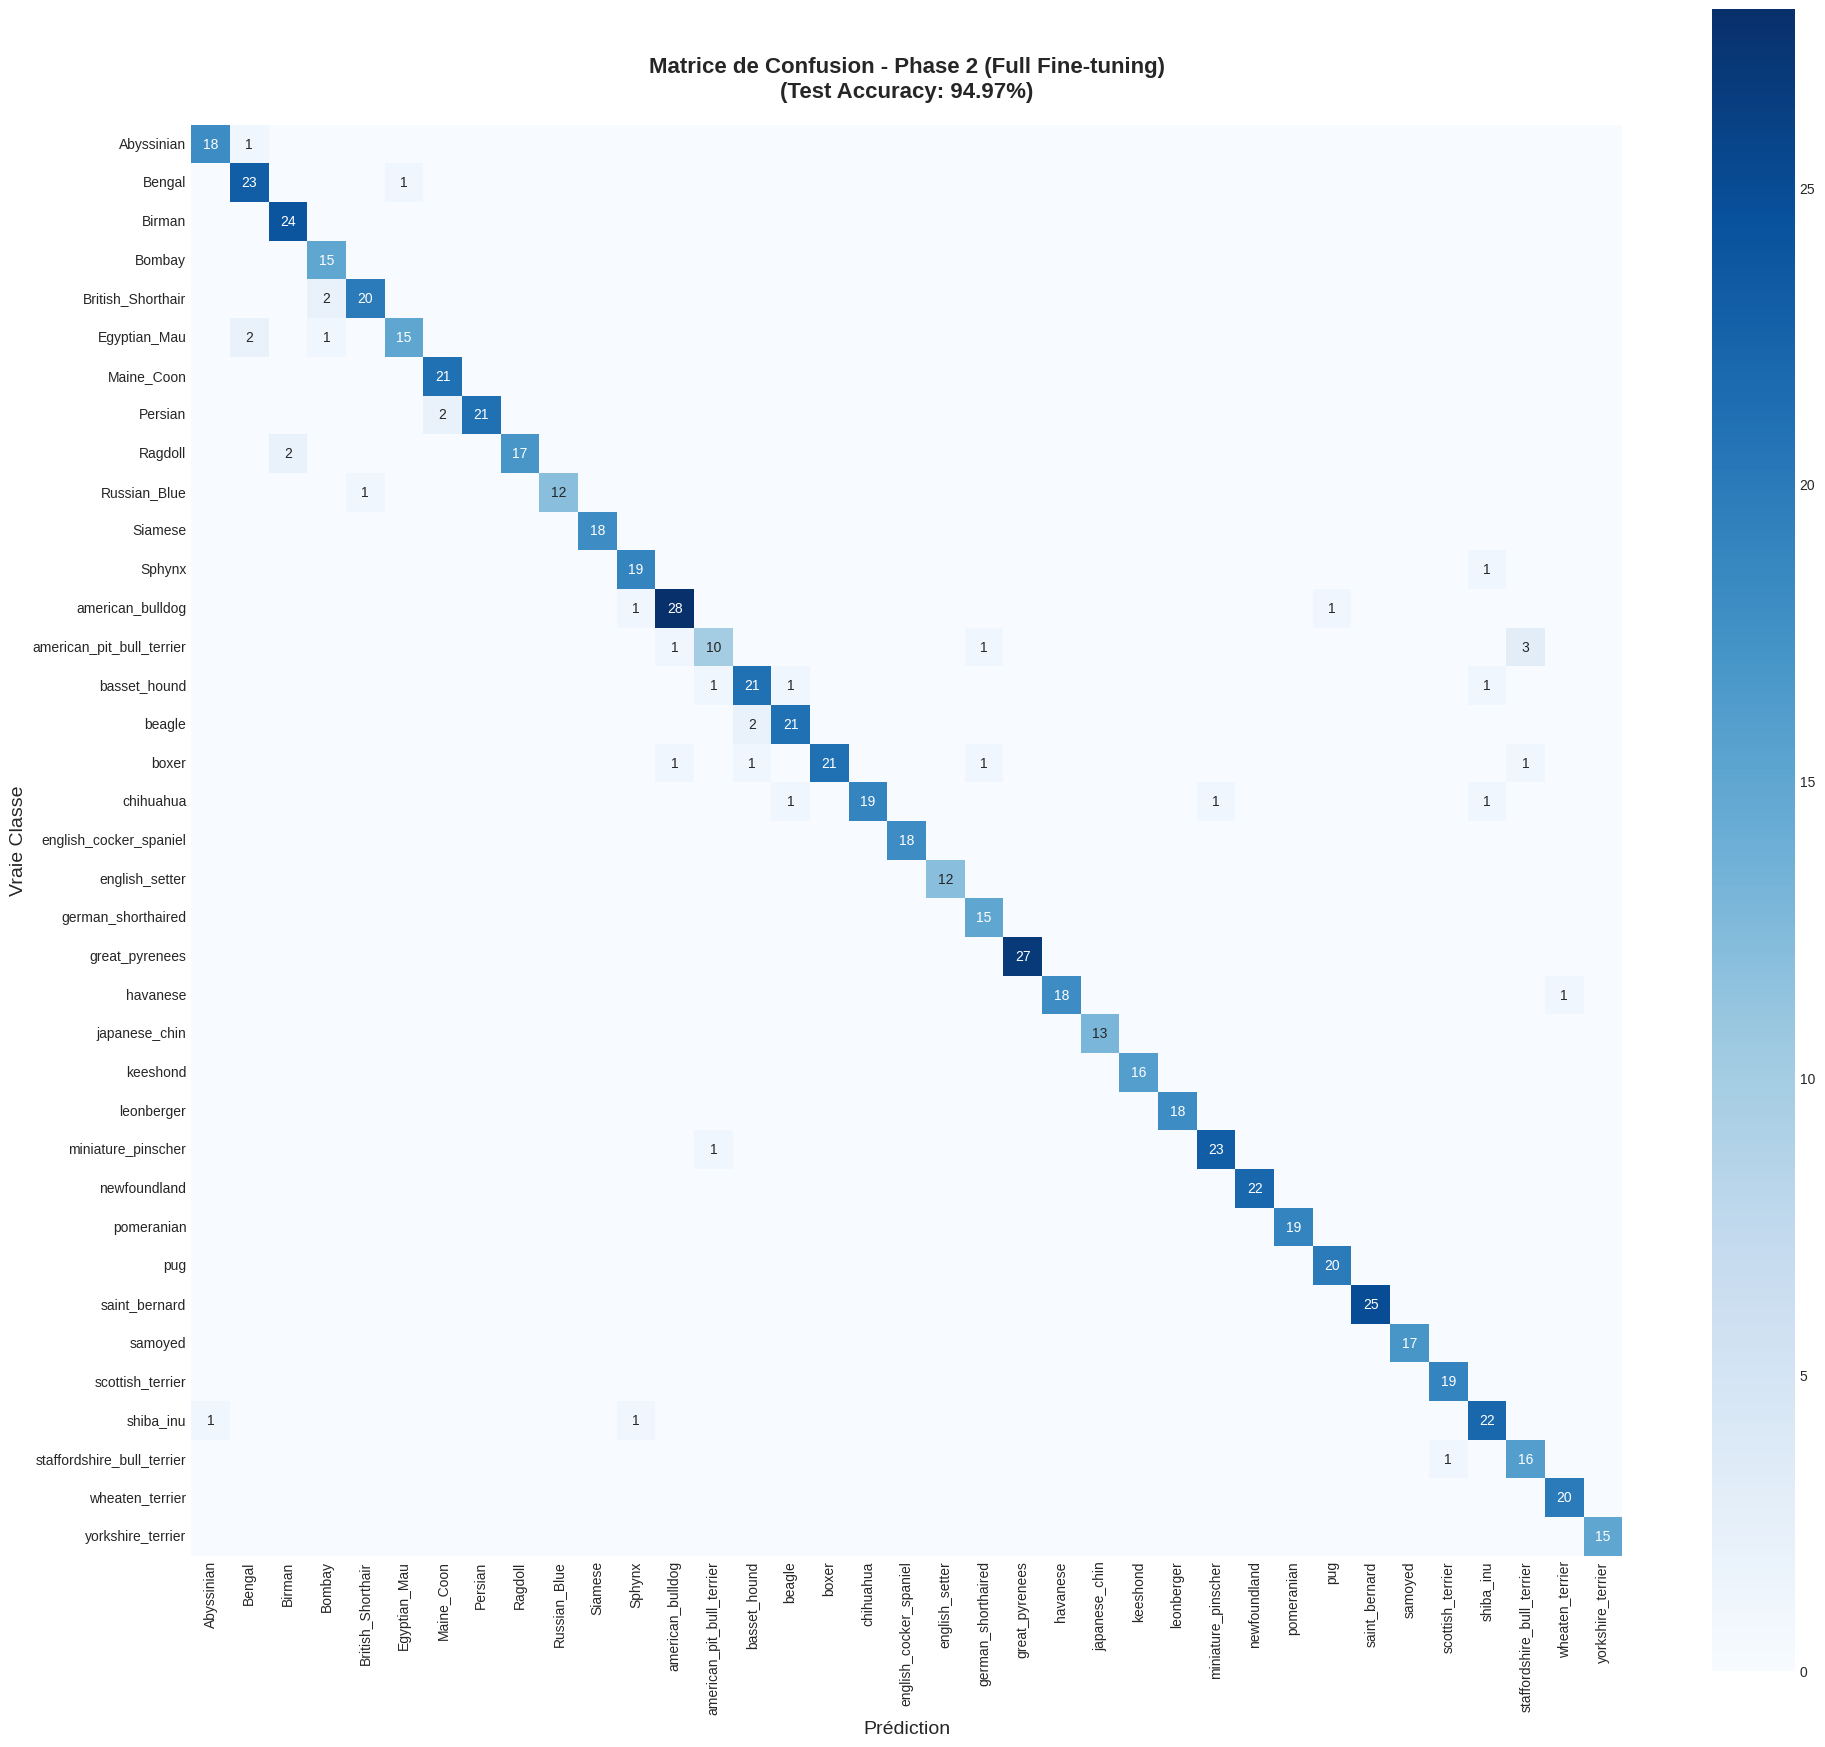

In [ ]:
# Afficher une matrice de confusion détaillée pour chaque modèle
for model_name in model_names[2:]:
    results = model_results[model_name]
    preds = results['predictions']
    labels = results['labels']
    label_to_name = results['label_to_name']
    num_classes = results['num_classes']
    
    # Calculer la matrice de confusion
    cm = confusion_matrix(labels, preds)
    cm_annot = np.where(cm == 0, "", cm)
    
    # Créer les labels de classes
    class_names = [label_to_name.get(i, f"Class_{i}") for i in range(num_classes)]
    
    # Grande figure pour chaque modèle
    plt.figure(figsize=(20, 18))
    sns.heatmap(
        cm,
        annot=cm_annot,
        fmt="",
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        square=True
    )
    
    plt.xlabel('Prédiction', fontsize=14)
    plt.ylabel('Vraie Classe', fontsize=14)
    plt.title(f'Matrice de Confusion - {model_name}\n(Test Accuracy: {results["accuracy"]:.2f}%)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

**Comme on peut voir sur la matrice de confusion, le modèle est très performant sur la majorité des classes, avec des taux de classification corrects très élevés sauf pour quelques classes spécifiques où des confusions subsistent, que nous allons étudier dans la suite.**

## **Analyse des classes les plus confondues**

In [ ]:
# Analyse des top 5 classes les plus confondues pour chaque modèle
print("="*80)
print("TOP 5 CLASSES LES PLUS CONFONDUES")
print("="*80)

for model_name in model_names[2:]:
    print(f"\n{model_name}")
    print("-" * 50)
    
    results = model_results[model_name]
    preds = results['predictions']
    labels = results['labels']
    label_to_name = results['label_to_name']
    
    # Calculer la matrice de confusion
    cm = confusion_matrix(labels, preds)
    
    # Extraire les confusions (hors diagonale)
    confusions = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j and cm[i, j] > 0:  # Pas sur la diagonale et au moins 1 erreur
                true_class = label_to_name.get(i, f"Class_{i}")
                pred_class = label_to_name.get(j, f"Class_{j}")
                confusions.append((true_class, pred_class, cm[i, j]))
    
    # Trier par nombre d'erreurs décroissant
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    # Afficher les top 5
    print(f"{'Rang':<4} {'Vraie Classe':<20} {'→':<3} {'Prédite':<20} {'Erreurs':<8}")
    print("-" * 60)
    
    for rank, (true_class, pred_class, errors) in enumerate(confusions[:5], 1):
        print(f"{rank:<4} {true_class:<20} {'→':<3} {pred_class:<20} {errors:<8}")

TOP 5 CLASSES LES PLUS CONFONDUES

Phase 2 (Full Fine-tuning)
--------------------------------------------------
Rang Vraie Classe         →   Prédite              Erreurs 
------------------------------------------------------------
1    american_pit_bull_terrier →   staffordshire_bull_terrier 3       
2    British_Shorthair    →   Bombay               2       
3    Egyptian_Mau         →   Bengal               2       
4    Persian              →   Maine_Coon           2       
5    Ragdoll              →   Birman               2       


**On remarque que certaines classes sont confondues car les espèces se ressemblent beaucoup visuellement (American Staffordshire Terrier et Staffordshire Bull Terrier, Egyptian Mau et Bengal, Ragdoll et Birman). Par contre, British Shorthair et Bombay ou bien Persian et Maine Coon sont des confusions plus surprenantes. Mais ces erreurs représentent une minorité des cas, ce qui montre que le modèle est globalement performant.**

## **Analyse d'interprétabilité avec Grad-CAM**

Dans cette section, nous analysons les erreurs du meilleur modèle (ResNet50 Full Fine-tuning) en utilisant Grad-CAM pour visualiser sur quelles parties de l'image le modèle se concentre lors de ses prédictions incorrectes. Et on regarde aussi les bonnes prédictions pour comprendre ce qui fonctionne bien.

In [ ]:
# Identifier les images mal classées du meilleur modèle
best_model_name = 'Phase 2 (Full Fine-tuning)'
best_results = model_results[best_model_name]

predictions = best_results['predictions']
true_labels = best_results['labels']
label_to_name = best_results['label_to_name']

# Trouver les indices des erreurs
error_indices = np.where(predictions != true_labels)[0]

# Prendre un échantillon des erreurs les plus intéressantes
np.random.seed(42)
sample_errors = np.random.choice(error_indices, min(8, len(error_indices)), replace=False)

for i, idx in enumerate(sample_errors):
    true_class = label_to_name[true_labels[idx]]
    pred_class = label_to_name[predictions[idx]]

GRAD-CAM - IMAGES BIEN CLASSÉES


/home/zanni/.conda/envs/HDDLtorch/lib/python3.12/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


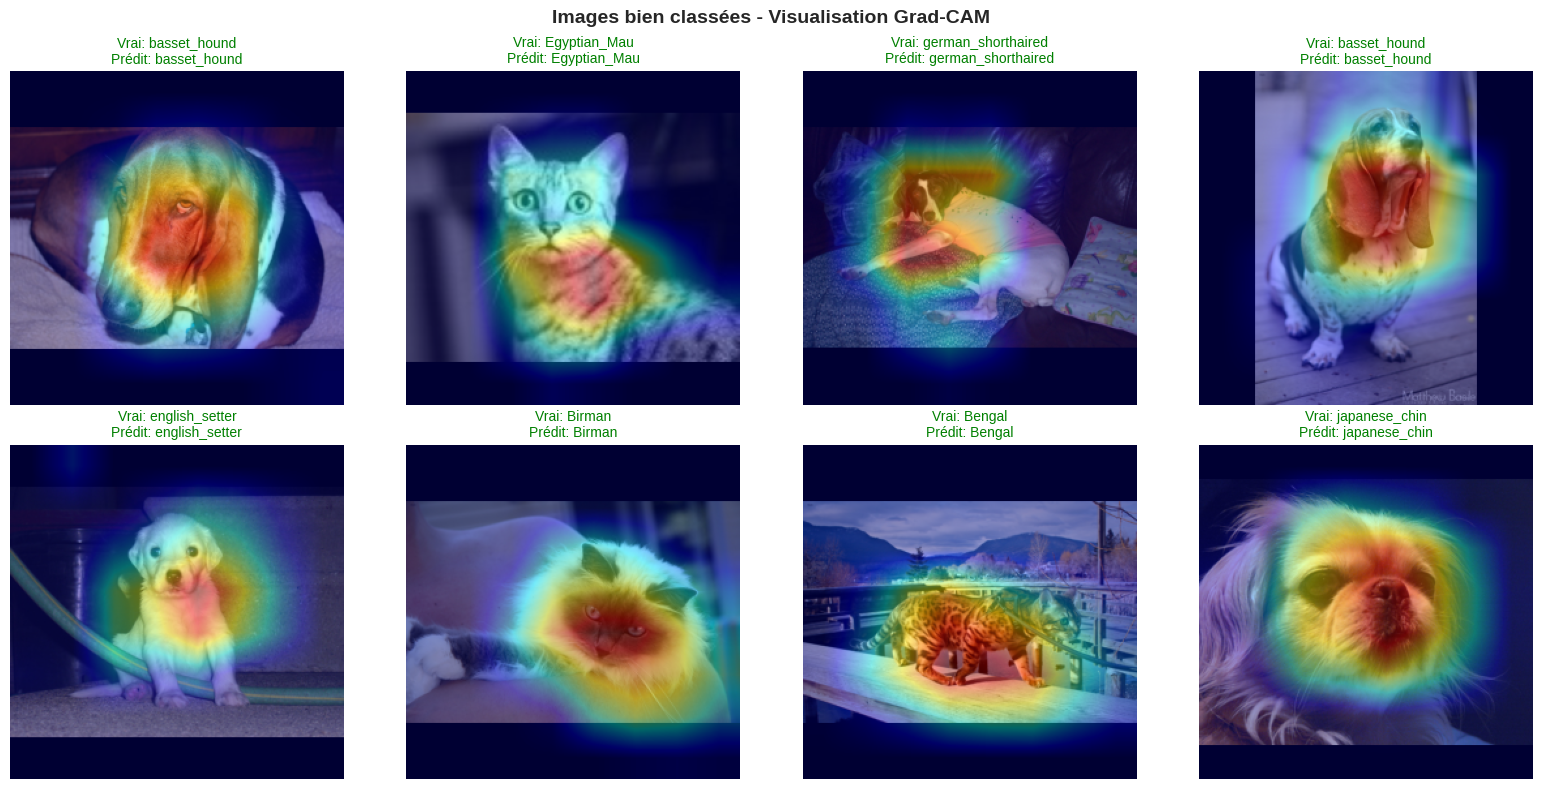


GRAD-CAM - IMAGES MAL CLASSÉES


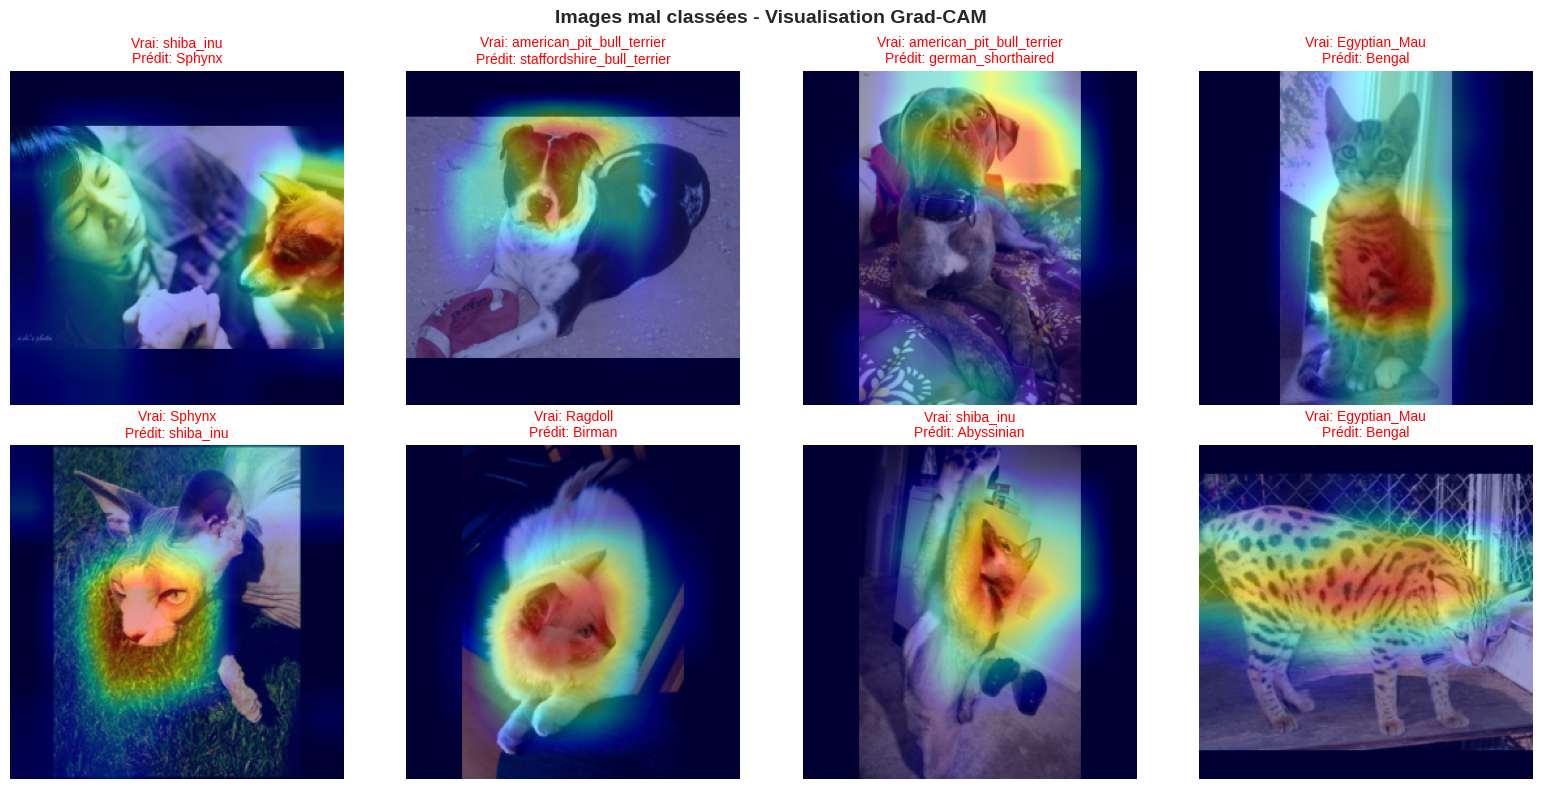

In [ ]:
import cv2
from PIL import Image

import torch.nn.functional as F
import torchvision.transforms as transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        
        # Hook pour capturer les gradients et activations
        hook1 = self.target_layer.register_forward_hook(self.save_activation)
        hook2 = self.target_layer.register_full_backward_hook(self.save_gradient)
        self.hooks.extend([hook1, hook2])
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
    
    def generate_cam(self, input_image, class_idx):
        # Ensure gradients are enabled for input
        input_image.requires_grad_(True)
        
        # Forward pass
        model_output = self.model(input_image)
        
        # Backward pass pour la classe cible
        self.model.zero_grad()
        model_output[0, class_idx].backward()
        
        # Vérifier que les gradients ont été capturés
        if self.gradients is None:
            print("Warning: No gradients captured!")
            return torch.zeros((224, 224), device=input_image.device)
        
        # Calcul du Grad-CAM
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Pondération des cartes d'activation par les gradients
        weights = torch.mean(gradients, dim=[1, 2])
        
        # Combinaison pondérée des cartes d'activation - ensure same device
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # Application de ReLU et normalisation
        cam = F.relu(cam)
        cam = cam / torch.max(cam) if torch.max(cam) > 0 else cam
        
        return cam

# Initialiser Grad-CAM pour le meilleur modèle
best_model = phase2_model
target_layer = best_model.resnet.layer4[-1].conv2  # Dernière couche conv avant le pooling

gradcam = GradCAM(best_model, target_layer)

# Fonction pour visualiser les résultats
def visualize_gradcam_results(images, predictions, true_labels, indices, title_prefix):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for i, idx in enumerate(indices):
        if i >= 8:
            break
            
        row = i // 4
        col = i % 4
        
        # Récupérer l'image originale du dataset
        image_tensor, label = test_loader.dataset[idx]
        image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        
        # Générer Grad-CAM pour la prédiction
        predicted_class = predictions[idx]
        cam = gradcam.generate_cam(image_tensor, predicted_class)
        
        # Convertir l'image pour l'affichage
        image_np = image_tensor.squeeze().cpu().detach().permute(1, 2, 0).numpy()
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
        # Clamp values to avoid clipping warnings
        image_np = np.clip(image_np, 0.0, 1.0)
        
        # Redimensionner la carte CAM à la taille de l'image
        cam_np = cam.detach().cpu().numpy()
        cam_resized = cv2.resize(cam_np, (image_np.shape[1], image_np.shape[0]))
        
        # Superposer la carte de chaleur sur l'image
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        superimposed = 0.6 * image_np + 0.4 * heatmap
        # Clamp final result to avoid clipping warnings
        superimposed = np.clip(superimposed, 0.0, 1.0)
        
        axes[row, col].imshow(superimposed)
        
        true_class_name = label_to_name[true_labels[idx]]
        pred_class_name = label_to_name[predictions[idx]]
        
        if true_labels[idx] == predictions[idx]:
            color = 'green'
        else:
            color = 'red'
            
        axes[row, col].set_title(
            f"Vrai: {true_class_name}\nPrédit: {pred_class_name}", 
            fontsize=10, color=color
        )
        axes[row, col].axis('off')
    
    # Masquer les axes non utilisés
    for i in range(len(indices), 8):
        row = i // 4
        col = i % 4
        axes[row, col].axis('off')
    
    plt.suptitle(f'{title_prefix} - Visualisation Grad-CAM', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 1. Visualiser des exemples bien classés
correct_indices = np.where(predictions == true_labels)[0]
np.random.seed(42)
sample_correct = np.random.choice(correct_indices, min(8, len(correct_indices)), replace=False)

print("="*60)
print("GRAD-CAM - IMAGES BIEN CLASSÉES")
print("="*60)

visualize_gradcam_results(None, predictions, true_labels, sample_correct, "Images bien classées")

# 2. Visualiser des exemples mal classés
print("\n" + "="*60)
print("GRAD-CAM - IMAGES MAL CLASSÉES")
print("="*60)

visualize_gradcam_results(None, predictions, true_labels, sample_errors, "Images mal classées")

**On remarque que le réseau s'attarde surtout sur les têtes des animaux pour déterminer la classe à laquelle il appartient, ou bien à son pelage, ce qui semble logique et assez similaire à ce que ferait un humain.**

**Par exemple, pour le Basset, il regarde les oreilles ou le regard qui sont caractéristiques de cette race.**

**On voit aussi qu'il confond Egyptian Mau et Bengal car il regarde le pelage, comme les deux pelages sont tâchetés et similaires, il lui arrive de confondre les deux.**